In [ ]:
import pandas as pd
csv_file_path = "/content/passenger_2025.csv"
df = pd.read_csv(csv_file_path, sep=";")
print(df.head())
print("\n--- Fayl haqqında məlumat ---")
df.info()

         Tarix (gün.ay.il)   Stansiya  Gündəlik gediş sayı
0  2025-01-01 00:00:00,000  20 Yanvar                29406
1  2025-01-02 00:00:00,000  20 Yanvar                31045
2  2025-01-03 00:00:00,000  20 Yanvar                33650
3  2025-01-04 00:00:00,000  20 Yanvar                34509
4  2025-01-05 00:00:00,000  20 Yanvar                28789

--- Fayl haqqında məlumat ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9855 entries, 0 to 9854
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Tarix (gün.ay.il)    9855 non-null   object
 1   Stansiya             9855 non-null   object
 2   Gündəlik gediş sayı  9855 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 231.1+ KB


In [ ]:
import re

def normalize_column_name(column_name: str) -> str:
    normalized = column_name.strip().lower()
    normalized = re.sub(r"[^\w\s]", "", normalized)
    normalized = re.sub(r"\s+", "_", normalized)
    return normalized

def clean_baku_metro_data(dataframe: pd.DataFrame) -> pd.DataFrame:
    cleaned = dataframe.copy()
    cleaned.columns = [normalize_column_name(column) for column in cleaned.columns]

    date_column = next(
        (column for column in cleaned.columns if "date" in column or "tarix" in column),
        None,
    )
    station_column = next(
        (column for column in cleaned.columns if "station" in column or "stansiya" in column),
        None,
    )
    passenger_column = next(
        (
            column
            for column in cleaned.columns
            if ("passenger" in column and "count" in column)
            or ("gediş" in column and "sayı" in column)
        ),
        None,
    )

    if date_column is None or station_column is None or passenger_column is None:
        raise ValueError("Could not identify the date, station, and passenger count columns.")

    cleaned[date_column] = pd.to_datetime(
        cleaned[date_column].astype(str).str.replace(",", ".", regex=False),
        format="mixed",
        dayfirst=True,
        errors="coerce",
    )
    cleaned[station_column] = cleaned[station_column].astype("string").str.strip()
    cleaned[passenger_column] = pd.to_numeric(cleaned[passenger_column], errors="coerce")

    cleaned = cleaned.sort_values([station_column, date_column]).reset_index(drop=True)
    cleaned[passenger_column] = cleaned.groupby(station_column)[passenger_column].transform(
        lambda series: series.interpolate(method="linear", limit_direction="both")
    )

    return cleaned

df_clean = clean_baku_metro_data(df)
print(df_clean.head())
df_clean.info()

  tarix_günayil   stansiya  gündəlik_gediş_sayı
0    2025-01-01  20 Yanvar                29406
1    2025-01-02  20 Yanvar                31045
2    2025-01-03  20 Yanvar                33650
3    2025-01-04  20 Yanvar                34509
4    2025-01-05  20 Yanvar                28789
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9855 entries, 0 to 9854
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   tarix_günayil        9855 non-null   datetime64[ns]
 1   stansiya             9855 non-null   string        
 2   gündəlik_gediş_sayı  9855 non-null   int64         
dtypes: datetime64[ns](1), int64(1), string(1)
memory usage: 231.1 KB


In [ ]:
import re
import unicodedata

import pandas as pd

class KinetixFeatureEngineer:
    def __init__(self, station_encoding="onehot", na_strategy="drop"):
        valid_encodings = {"onehot", "target", "none"}
        valid_na_strategies = {"drop", "bfill", "keep"}
        if station_encoding not in valid_encodings:
            raise ValueError(f"station_encoding must be one of {valid_encodings}.")
        if na_strategy not in valid_na_strategies:
            raise ValueError(f"na_strategy must be one of {valid_na_strategies}.")

        self.station_encoding = station_encoding
        self.na_strategy = na_strategy
        self.station_target_map_ = None
        self.global_target_mean_ = None
        self.feature_columns_ = None

    @staticmethod
    def _normalize_column_name(column_name: str) -> str:
        normalized = column_name.strip().lower()
        normalized = re.sub(r"[^\w\s]", "", normalized)
        normalized = re.sub(r"\s+", "_", normalized)
        return normalized

    @staticmethod
    def _normalize_station_key(station_name: object) -> str:
        if pd.isna(station_name):
            return ""
        text = str(station_name).strip().lower()
        replacements = str.maketrans({
            "ə": "e",
            "ğ": "g",
            "ı": "i",
            "ç": "c",
            "ö": "o",
            "ş": "s",
            "ü": "u",
            "һ": "h",
        })
        text = unicodedata.normalize("NFKD", text).translate(replacements)
        text = "".join(character for character in text if not unicodedata.combining(character))
        text = re.sub(r"[^a-z0-9]+", " ", text)
        return " ".join(text.split())

    @staticmethod
    def _build_major_azerbaijan_holidays() -> set[pd.Timestamp]:
        holiday_strings = [
            "2024-01-01", "2024-01-02",
            "2024-03-08",
            "2024-03-20", "2024-03-21", "2024-03-22", "2024-03-23", "2024-03-24",
            "2024-05-09", "2024-05-28",
            "2024-06-15", "2024-06-26",
            "2024-11-08", "2024-11-09",
            "2024-12-31",
            "2025-01-01", "2025-01-02",
            "2025-03-08",
            "2025-03-20", "2025-03-21", "2025-03-22", "2025-03-23", "2025-03-24",
            "2025-05-09", "2025-05-28",
            "2025-06-15", "2025-06-26",
            "2025-11-08", "2025-11-09",
            "2025-12-31",
        ]
        return {pd.Timestamp(value).normalize() for value in holiday_strings}

    def _canonicalize_columns(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        engineered = dataframe.copy()
        engineered.columns = [self._normalize_column_name(column) for column in engineered.columns]

        column_map = {}
        for column in engineered.columns:
            if column in {"date", "station_name", "passenger_count"}:
                continue
            if "date" in column or "tarix" in column:
                column_map[column] = "date"
            elif "station" in column or "stansiya" in column:
                column_map[column] = "station_name"
            elif ("passenger" in column and "count" in column) or ("gedis" in column and "sayi" in column) or ("gediş" in column and "sayı" in column):
                column_map[column] = "passenger_count"

        engineered = engineered.rename(columns=column_map)

        required = {"date", "station_name", "passenger_count"}
        missing = required.difference(engineered.columns)
        if missing:
            raise ValueError(f"Missing required columns after canonicalization: {sorted(missing)}")

        engineered["date"] = pd.to_datetime(
            engineered["date"].astype(str).str.replace(",", ".", regex=False),
            format="mixed",
            dayfirst=True,
            errors="coerce",
        )
        engineered["station_name"] = engineered["station_name"].astype("string").str.strip()
        engineered["passenger_count"] = pd.to_numeric(engineered["passenger_count"], errors="coerce")

        engineered.columns = [self._normalize_column_name(column) for column in engineered.columns]
        return engineered

    def _aggregate_station_time_series(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        engineered = dataframe.dropna(subset=["date", "station_name", "passenger_count"]).copy()
        engineered = (
            engineered
            .groupby(["station_name", "date"], as_index=False)["passenger_count"]
            .sum()
            .sort_values(["station_name", "date"])
            .reset_index(drop=True)
        )
        return engineered

    def _add_temporal_features(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        engineered = dataframe.copy()
        engineered["day_of_week"] = engineered["date"].dt.dayofweek
        engineered["day_of_month"] = engineered["date"].dt.day
        engineered["month"] = engineered["date"].dt.month
        engineered["is_weekend"] = engineered["day_of_week"] >= 5
        return engineered

    def _add_local_context_features(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        engineered = dataframe.copy()
        holidays = self._build_major_azerbaijan_holidays()
        normalized_dates = engineered["date"].dt.normalize()
        engineered["is_holiday_az"] = normalized_dates.isin(holidays)

        month = engineered["date"].dt.month
        day = engineered["date"].dt.day
        autumn_term = (month > 9) | ((month == 9) & (day >= 15))
        spring_term = ((month >= 2) & (month < 5)) | ((month == 5) & (day <= 31))
        engineered["is_academic_season"] = autumn_term | spring_term
        return engineered

    def _add_station_typology(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        engineered = dataframe.copy()
        station_keys = engineered["station_name"].map(self._normalize_station_key)

        transfer_hubs = {"28 may", "memar ecemi", "memar ajami"}
        student_hubs = {"elmler akademiyasi", "genclik"}

        engineered["is_transfer_hub"] = station_keys.isin(transfer_hubs)
        engineered["is_student_hub"] = station_keys.isin(student_hubs)
        return engineered

    def _fit_station_encoder(self, dataframe: pd.DataFrame) -> None:
        if self.station_encoding == "target":
            self.station_target_map_ = dataframe.groupby("station_name")["passenger_count"].mean().to_dict()
            self.global_target_mean_ = float(dataframe["passenger_count"].mean())

    def _apply_station_encoding(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        engineered = dataframe.copy()
        if self.station_encoding == "onehot":
            station_dummies = pd.get_dummies(engineered["station_name"], prefix="station", dtype=int)
            engineered = pd.concat([engineered, station_dummies], axis=1)
        elif self.station_encoding == "target":
            if self.station_target_map_ is None:
                raise ValueError("Target encoder has not been fitted.")
            engineered["station_target_encoded"] = engineered["station_name"].map(self.station_target_map_).fillna(self.global_target_mean_)
        return engineered

    def _add_lag_features(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        engineered = dataframe.copy().sort_values(["station_name", "date"]).reset_index(drop=True)

        lag_1_source = engineered[["station_name", "date", "passenger_count"]].copy()
        lag_1_source["date"] = lag_1_source["date"] + pd.Timedelta(days=1)
        lag_1_source = lag_1_source.rename(columns={"passenger_count": "lag_1_day"})

        lag_7_source = engineered[["station_name", "date", "passenger_count"]].copy()
        lag_7_source["date"] = lag_7_source["date"] + pd.Timedelta(days=7)
        lag_7_source = lag_7_source.rename(columns={"passenger_count": "lag_7_days"})

        engineered = engineered.merge(lag_1_source, on=["station_name", "date"], how="left")
        engineered = engineered.merge(lag_7_source, on=["station_name", "date"], how="left")

        rolling_mean = (
            engineered
            .groupby("station_name")
            .rolling(window="3D", on="date", min_periods=1)["passenger_count"]
            .mean()
            .reset_index(level=0, drop=True)
        )
        engineered["rolling_mean_3_days"] = rolling_mean.to_numpy()
        return engineered

    def _handle_time_series_nans(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        engineered = dataframe.copy()
        lag_columns = ["lag_1_day", "lag_7_days", "rolling_mean_3_days"]

        if self.na_strategy == "drop":
            engineered = engineered.dropna(subset=lag_columns).reset_index(drop=True)
        elif self.na_strategy == "bfill":
            engineered[lag_columns] = engineered.groupby("station_name")[lag_columns].transform(lambda frame: frame.bfill())
        return engineered

    def fit(self, dataframe: pd.DataFrame):
        engineered = self._canonicalize_columns(dataframe)
        engineered = self._aggregate_station_time_series(engineered)
        self._fit_station_encoder(engineered)
        return self

    def transform(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        engineered = self._canonicalize_columns(dataframe)
        engineered = self._aggregate_station_time_series(engineered)
        engineered = self._add_temporal_features(engineered)
        engineered = self._add_local_context_features(engineered)
        engineered = self._add_station_typology(engineered)
        engineered = self._apply_station_encoding(engineered)
        engineered = self._add_lag_features(engineered)
        engineered = self._handle_time_series_nans(engineered)
        engineered = engineered.sort_values(["station_name", "date"]).reset_index(drop=True)
        self.feature_columns_ = engineered.columns.tolist()
        return engineered

    def fit_transform(self, dataframe: pd.DataFrame) -> pd.DataFrame:
        return self.fit(dataframe).transform(dataframe)


feature_engineer = KinetixFeatureEngineer(station_encoding="onehot", na_strategy="drop")
df_features = feature_engineer.fit_transform(df_clean)

selected_columns = [
    "date",
    "station_name",
    "passenger_count",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "is_holiday_az",
    "is_academic_season",
    "is_transfer_hub",
    "is_student_hub",
    "lag_1_day",
    "lag_7_days",
    "rolling_mean_3_days",
]

print(df_features[selected_columns].head())
print("Feature matrix shape:", df_features.shape)
print("Unique station-date rows:", df_features[["station_name", "date"]].drop_duplicates().shape[0])
print("Null counts in lag features:")
print(df_features[["lag_1_day", "lag_7_days", "rolling_mean_3_days"]].isna().sum())

        date station_name  passenger_count  day_of_week  day_of_month  month  \
0 2025-01-08    20 Yanvar            50211            2             8      1   
1 2025-01-09    20 Yanvar            51538            3             9      1   
2 2025-01-10    20 Yanvar            55388            4            10      1   
3 2025-01-11    20 Yanvar            42566            5            11      1   
4 2025-01-12    20 Yanvar            33632            6            12      1   

   is_weekend  is_holiday_az  is_academic_season  is_transfer_hub  \
0       False          False               False            False   
1       False          False               False            False   
2       False          False               False            False   
3        True          False               False            False   
4        True          False               False            False   

   is_student_hub  lag_1_day  lag_7_days  rolling_mean_3_days  
0           False    47256.0     29406.0

In [ ]:
# Strict Chronological Train-Test Split (80/20) for Kinetix
if "df_features" not in globals():
    raise ValueError("df_features is not defined. Run the feature engineering cell first.")

master_df = df_features.copy()

# 1) Strict Temporal Sorting
sort_columns = ["date"]
if "hour" in master_df.columns:
    sort_columns.append("hour")
master_df = master_df.sort_values(sort_columns, ascending=True).reset_index(drop=True)

# 2) Define Target (y) and Feature Matrix (X)
y = master_df["passenger_count"].copy()

explicit_drop_cols = {"passenger_count", "date", "station_name"}
object_columns = set(master_df.select_dtypes(include=["object", "string"]).columns.tolist())
drop_columns = list(explicit_drop_cols.union(object_columns))

X = master_df.drop(columns=drop_columns, errors="ignore").copy()

# 3) Index-Based Splitting (80/20)
split_index = int(len(master_df) * 0.80)

X_train = X.iloc[:split_index].copy()
y_train = y.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_test = y.iloc[split_index:].copy()

train_dates = master_df["date"].iloc[:split_index]
test_dates = master_df["date"].iloc[split_index:]

# 4) Validation Printout
print("Shapes:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)

print("\nDate ranges:")
print("Train min date:", train_dates.min())
print("Train max date:", train_dates.max())
print("Test  min date:", test_dates.min())
print("Test  max date:", test_dates.max())

print("\nStrict non-overlap check (train_max < test_min):", train_dates.max() < test_dates.min())
print("Dropped columns from X:", sorted(drop_columns))

Shapes:
X_train: (7732, 38) | y_train: (7732,)
X_test : (1934, 38) | y_test : (1934,)

Date ranges:
Train min date: 2025-01-08 00:00:00
Train max date: 2025-10-21 00:00:00
Test  min date: 2025-10-21 00:00:00
Test  max date: 2025-12-31 00:00:00

Strict non-overlap check (train_max < test_min): False
Dropped columns from X: ['date', 'passenger_count', 'station_name']


In [8]:
import xgboost as xgb

# 1) Model Initialization
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="rmse",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
 )

# 2) Model Training with Validation
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100,
 )

# 3) Post-Training Output
print(
    f"✅ XGBoost training complete | best_iteration={xgb_model.best_iteration} | best_score={xgb_model.best_score:.6f}"
)

y_pred = xgb_model.predict(X_test)
print(f"Predictions generated: {len(y_pred)}")

[0]	validation_0-rmse:16328.63565	validation_1-rmse:18969.74761
[100]	validation_0-rmse:1467.84162	validation_1-rmse:2341.30288
[166]	validation_0-rmse:1104.39924	validation_1-rmse:2334.50015
✅ XGBoost training complete | best_iteration=116 | best_score=2331.785837
Predictions generated: 1934


KINETIX MODEL EVALUATION REPORT
MAE : 1,170.431
MAE meaning: average absolute passenger miscalculation per prediction.
RMSE: 2,331.786
RMSE meaning: penalizes large errors heavily (critical for rush-hour under/overestimation).
R²  : 0.9859
R² meaning: fraction of passenger-flow variance explained by Kinetix.


/tmp/ipykernel_392/736281069.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_15, x="importance", y="feature", palette="viridis")


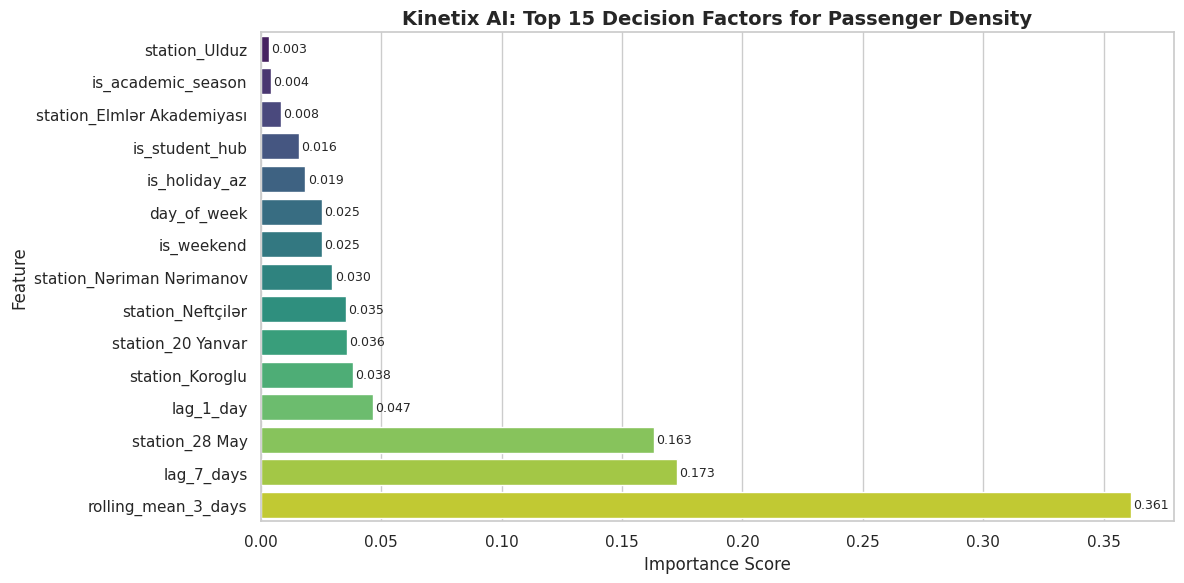

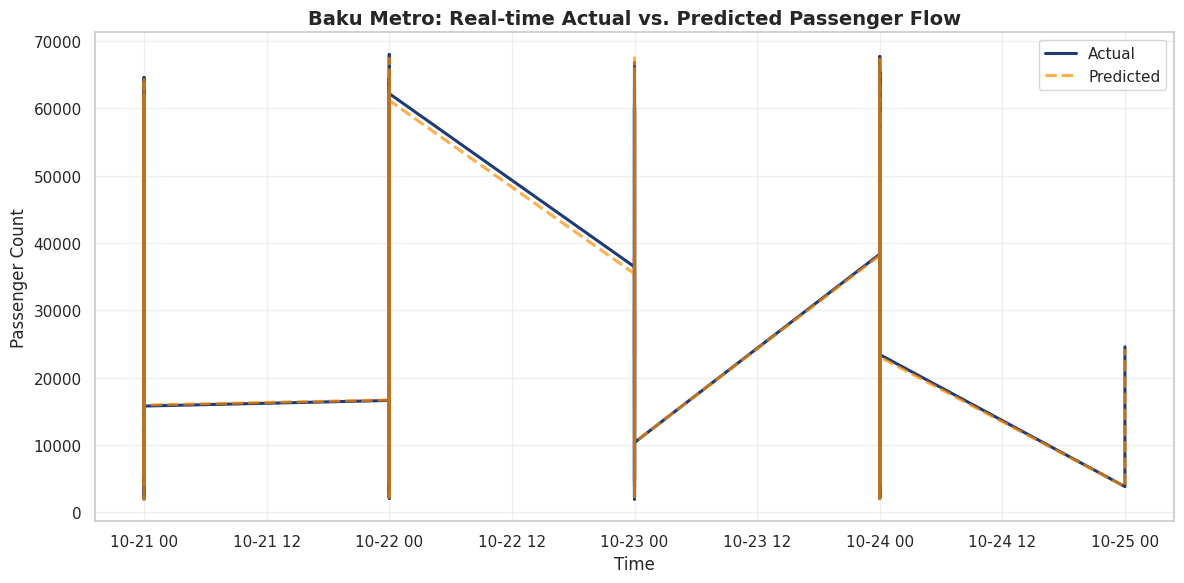

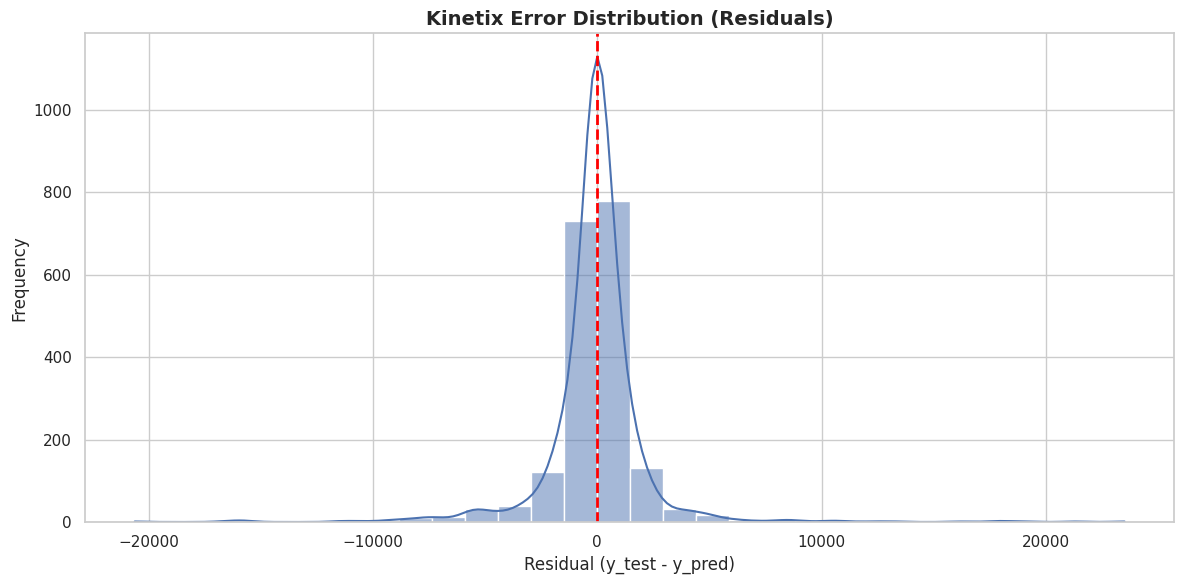

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

xgb_model_obj = globals().get("xgb_model")
X_train_obj = globals().get("X_train")
X_test_obj = globals().get("X_test")
y_test_obj = globals().get("y_test")
y_pred_obj = globals().get("y_pred")

missing_objects = []
if xgb_model_obj is None:
    missing_objects.append("xgb_model")
if X_train_obj is None:
    missing_objects.append("X_train")
if X_test_obj is None:
    missing_objects.append("X_test")
if y_test_obj is None:
    missing_objects.append("y_test")
if y_pred_obj is None:
    missing_objects.append("y_pred")

if missing_objects:
    print(f"Skipping evaluation. Missing required objects: {missing_objects}")
    print("Run the train/test split cell and model training cell first, then re-run this evaluation cell.")
else:
    # Ensure aligned vectors
    y_test_eval = pd.Series(y_test_obj).reset_index(drop=True)
    y_pred_eval = pd.Series(y_pred_obj).reset_index(drop=True)

    # 1) Comprehensive Error Metrics Report
    mae = mean_absolute_error(y_test_eval, y_pred_eval)
    rmse = np.sqrt(mean_squared_error(y_test_eval, y_pred_eval))
    r2 = r2_score(y_test_eval, y_pred_eval)

    print("=" * 80)
    print("KINETIX MODEL EVALUATION REPORT")
    print("=" * 80)
    print(f"MAE : {mae:,.3f}")
    print("MAE meaning: average absolute passenger miscalculation per prediction.")
    print(f"RMSE: {rmse:,.3f}")
    print("RMSE meaning: penalizes large errors heavily (critical for rush-hour under/overestimation).")
    print(f"R²  : {r2:,.4f}")
    print("R² meaning: fraction of passenger-flow variance explained by Kinetix.")

    # 2) Feature Importance (Top 15)
    feature_importance = pd.DataFrame({
        "feature": X_train_obj.columns,
        "importance": xgb_model_obj.feature_importances_,
    }).sort_values("importance", ascending=False)

    top_15 = feature_importance.head(15).sort_values("importance", ascending=True)

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=top_15, x="importance", y="feature", palette="viridis")
    plt.title("Kinetix AI: Top 15 Decision Factors for Passenger Density", fontsize=14, fontweight="bold")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")

    for patch in ax.patches:
        width = patch.get_width()
        y_loc = patch.get_y() + patch.get_height() / 2
        ax.text(width + 0.001, y_loc, f"{width:.3f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    # 3) Actual vs. Predicted Timeline (Sanity Check)
    if "master_df" in globals() and "split_index" in globals() and "date" in master_df.columns:
        test_timeline = pd.Series(master_df.iloc[split_index:]["date"]).reset_index(drop=True)
    else:
        test_timeline = pd.Series(range(len(y_test_eval)), name="step")

    is_hourly = False
    if "master_df" in globals() and "date" in master_df.columns:
        unique_hours = pd.to_datetime(master_df["date"], errors="coerce").dt.hour.nunique()
        is_hourly = unique_hours > 1

    window_size = 168 if is_hourly else min(100, len(y_test_eval))
    window_slice = slice(0, window_size)

    plot_x = test_timeline.iloc[window_slice]
    actual_window = y_test_eval.iloc[window_slice]
    pred_window = y_pred_eval.iloc[window_slice]

    plt.figure(figsize=(12, 6))
    plt.plot(plot_x, actual_window, color="#1f3b75", linewidth=2.2, label="Actual")
    plt.plot(plot_x, pred_window, color="#ff8c00", linestyle="--", linewidth=2.2, alpha=0.7, label="Predicted")
    plt.title("Baku Metro: Real-time Actual vs. Predicted Passenger Flow", fontsize=14, fontweight="bold")
    plt.xlabel("Time")
    plt.ylabel("Passenger Count")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4) Residual Analysis (Error Distribution)
    residuals = y_test_eval - y_pred_eval

    plt.figure(figsize=(12, 6))
    sns.histplot(residuals, bins=30, kde=True, color="#4c72b0", edgecolor="white")
    plt.axvline(0, color="red", linestyle="--", linewidth=2)
    plt.title("Kinetix Error Distribution (Residuals)", fontsize=14, fontweight="bold")
    plt.xlabel("Residual (y_test - y_pred)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

KINETIX MODEL EVALUATION REPORT
MAE : 1,170.431
MAE meaning: average absolute passenger miscalculation per prediction.
RMSE: 2,331.786
RMSE meaning: penalizes large errors heavily (critical for rush-hour under/overestimation).
R²  : 0.9859
R² meaning: fraction of passenger-flow variance explained by Kinetix.


/tmp/ipykernel_392/736281069.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_15, x="importance", y="feature", palette="viridis")


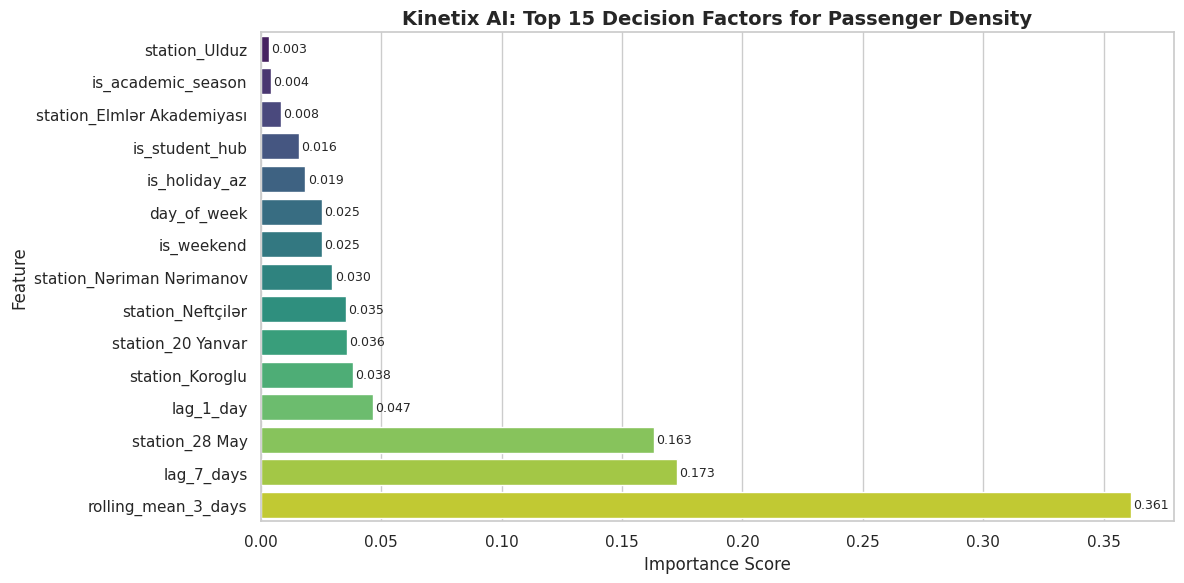

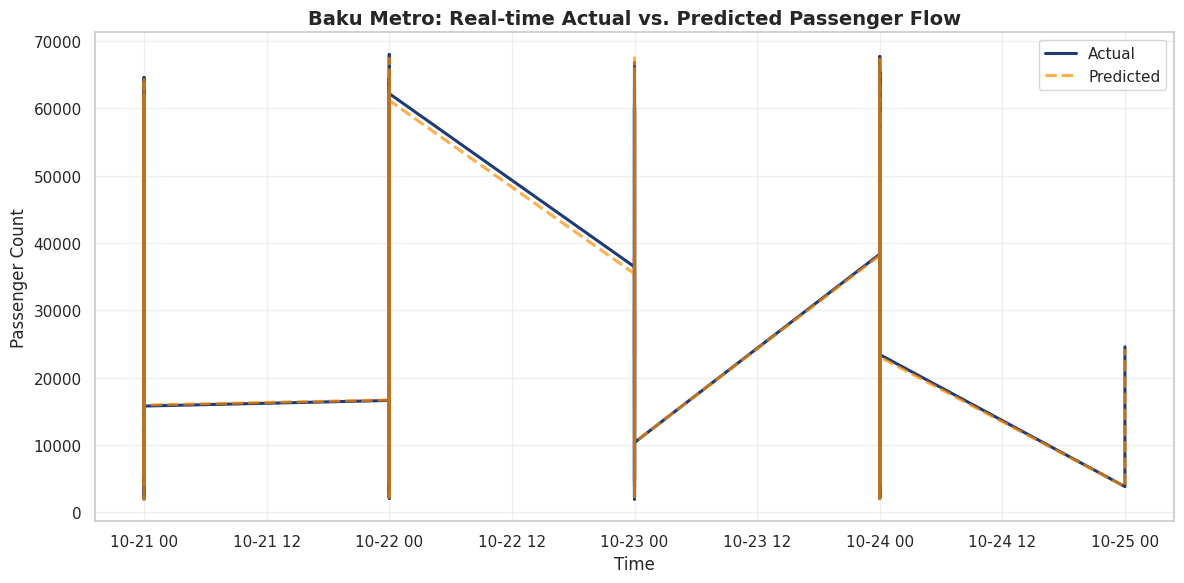

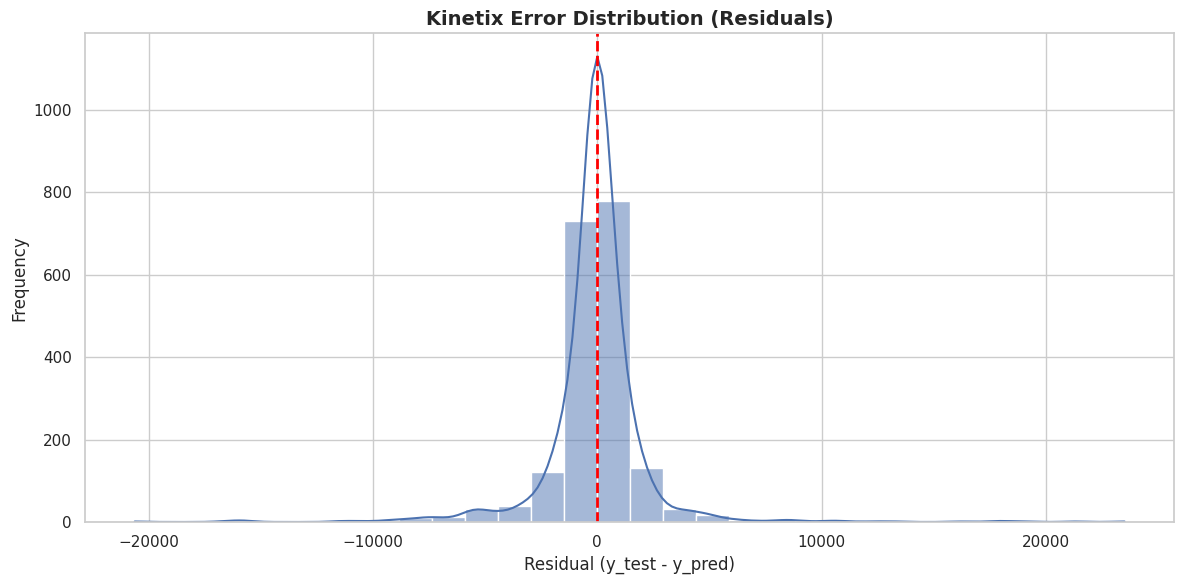

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

xgb_model_obj = globals().get("xgb_model")
X_train_obj = globals().get("X_train")
X_test_obj = globals().get("X_test")
y_test_obj = globals().get("y_test")
y_pred_obj = globals().get("y_pred")

missing_objects = []
if xgb_model_obj is None:
    missing_objects.append("xgb_model")
if X_train_obj is None:
    missing_objects.append("X_train")
if X_test_obj is None:
    missing_objects.append("X_test")
if y_test_obj is None:
    missing_objects.append("y_test")
if y_pred_obj is None:
    missing_objects.append("y_pred")

if missing_objects:
    print(f"Skipping evaluation. Missing required objects: {missing_objects}")
    print("Run the train/test split cell and model training cell first, then re-run this evaluation cell.")
else:
    # Ensure aligned vectors
    y_test_eval = pd.Series(y_test_obj).reset_index(drop=True)
    y_pred_eval = pd.Series(y_pred_obj).reset_index(drop=True)

    # 1) Comprehensive Error Metrics Report
    mae = mean_absolute_error(y_test_eval, y_pred_eval)
    rmse = np.sqrt(mean_squared_error(y_test_eval, y_pred_eval))
    r2 = r2_score(y_test_eval, y_pred_eval)

    print("=" * 80)
    print("KINETIX MODEL EVALUATION REPORT")
    print("=" * 80)
    print(f"MAE : {mae:,.3f}")
    print("MAE meaning: average absolute passenger miscalculation per prediction.")
    print(f"RMSE: {rmse:,.3f}")
    print("RMSE meaning: penalizes large errors heavily (critical for rush-hour under/overestimation).")
    print(f"R²  : {r2:,.4f}")
    print("R² meaning: fraction of passenger-flow variance explained by Kinetix.")

    # 2) Feature Importance (Top 15)
    feature_importance = pd.DataFrame({
        "feature": X_train_obj.columns,
        "importance": xgb_model_obj.feature_importances_,
    }).sort_values("importance", ascending=False)

    top_15 = feature_importance.head(15).sort_values("importance", ascending=True)

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=top_15, x="importance", y="feature", palette="viridis")
    plt.title("Kinetix AI: Top 15 Decision Factors for Passenger Density", fontsize=14, fontweight="bold")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")

    for patch in ax.patches:
        width = patch.get_width()
        y_loc = patch.get_y() + patch.get_height() / 2
        ax.text(width + 0.001, y_loc, f"{width:.3f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    # 3) Actual vs. Predicted Timeline (Sanity Check)
    if "master_df" in globals() and "split_index" in globals() and "date" in master_df.columns:
        test_timeline = pd.Series(master_df.iloc[split_index:]["date"]).reset_index(drop=True)
    else:
        test_timeline = pd.Series(range(len(y_test_eval)), name="step")

    is_hourly = False
    if "master_df" in globals() and "date" in master_df.columns:
        unique_hours = pd.to_datetime(master_df["date"], errors="coerce").dt.hour.nunique()
        is_hourly = unique_hours > 1

    window_size = 168 if is_hourly else min(100, len(y_test_eval))
    window_slice = slice(0, window_size)

    plot_x = test_timeline.iloc[window_slice]
    actual_window = y_test_eval.iloc[window_slice]
    pred_window = y_pred_eval.iloc[window_slice]

    plt.figure(figsize=(12, 6))
    plt.plot(plot_x, actual_window, color="#1f3b75", linewidth=2.2, label="Actual")
    plt.plot(plot_x, pred_window, color="#ff8c00", linestyle="--", linewidth=2.2, alpha=0.7, label="Predicted")
    plt.title("Baku Metro: Real-time Actual vs. Predicted Passenger Flow", fontsize=14, fontweight="bold")
    plt.xlabel("Time")
    plt.ylabel("Passenger Count")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4) Residual Analysis (Error Distribution)
    residuals = y_test_eval - y_pred_eval

    plt.figure(figsize=(12, 6))
    sns.histplot(residuals, bins=30, kde=True, color="#4c72b0", edgecolor="white")
    plt.axvline(0, color="red", linestyle="--", linewidth=2)
    plt.title("Kinetix Error Distribution (Residuals)", fontsize=14, fontweight="bold")
    plt.xlabel("Residual (y_test - y_pred)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

1) BASIC DATA PROFILING & CLEANING CHECK

Statistical summary of passenger_count:
       passenger_count
count      9855.000000
mean      23014.019990
std       17673.697162
min         182.000000
25%        7477.500000
50%       20899.000000
75%       32935.000000
max       77392.000000

Missing values per column:
date               0
station_name       0
passenger_count    0
hour_of_day        0
day_of_week        0
day_name           0
month              0
date_only          0
dtype: int64

Potential outliers - zero daytime counts: 0

Potential outliers - high spikes (>109,307.50): 0


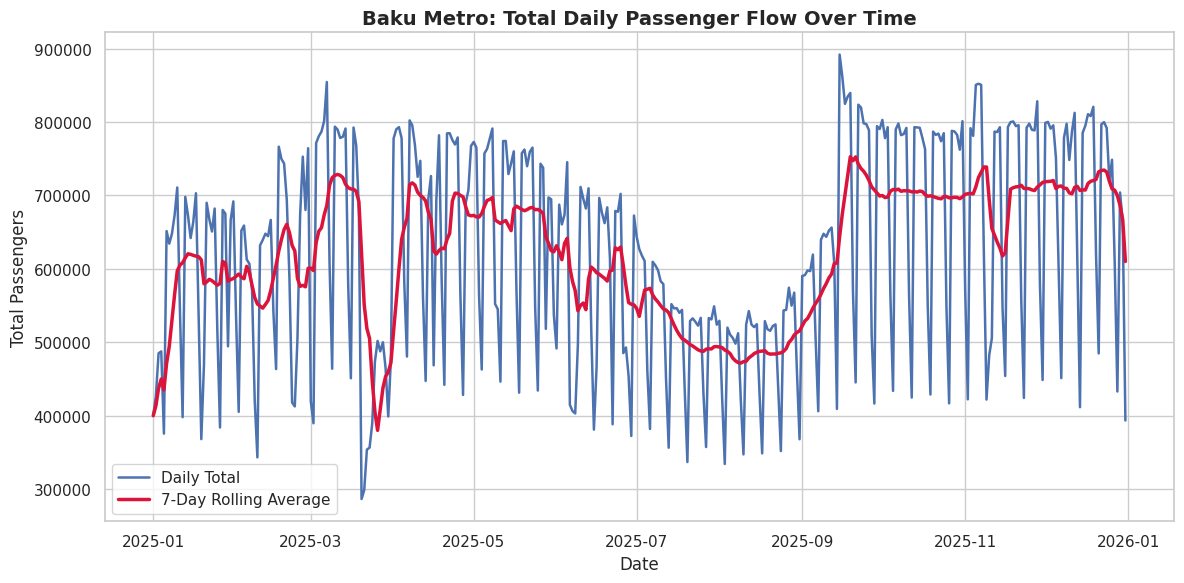

/tmp/ipykernel_392/851310567.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_by_dow, x="day_name", y="avg_passenger_count", palette="Blues_d", ax=axes[0])
/tmp/ipykernel_392/851310567.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_by_month, x="month", y="avg_passenger_count", palette="viridis", ax=axes[1])


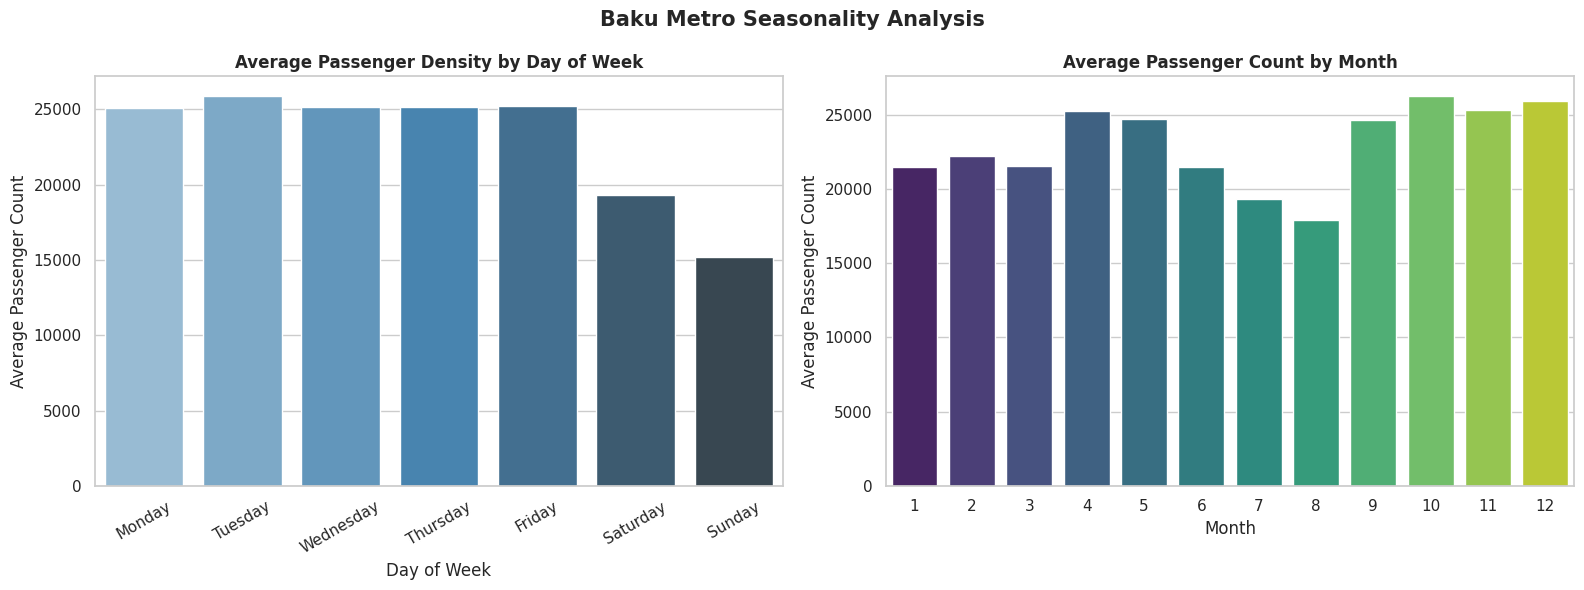

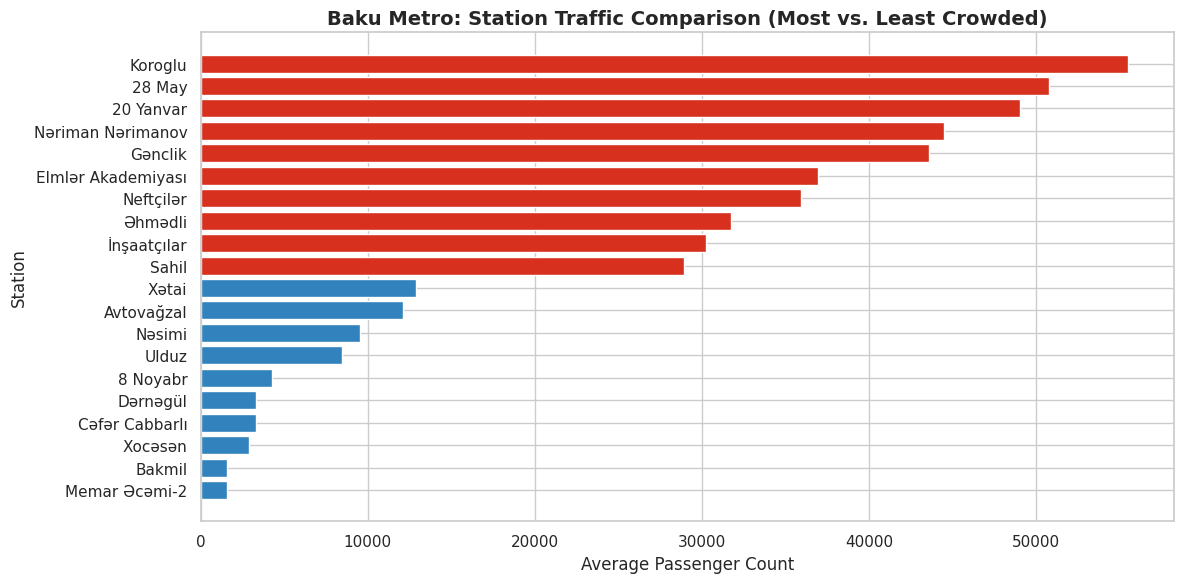

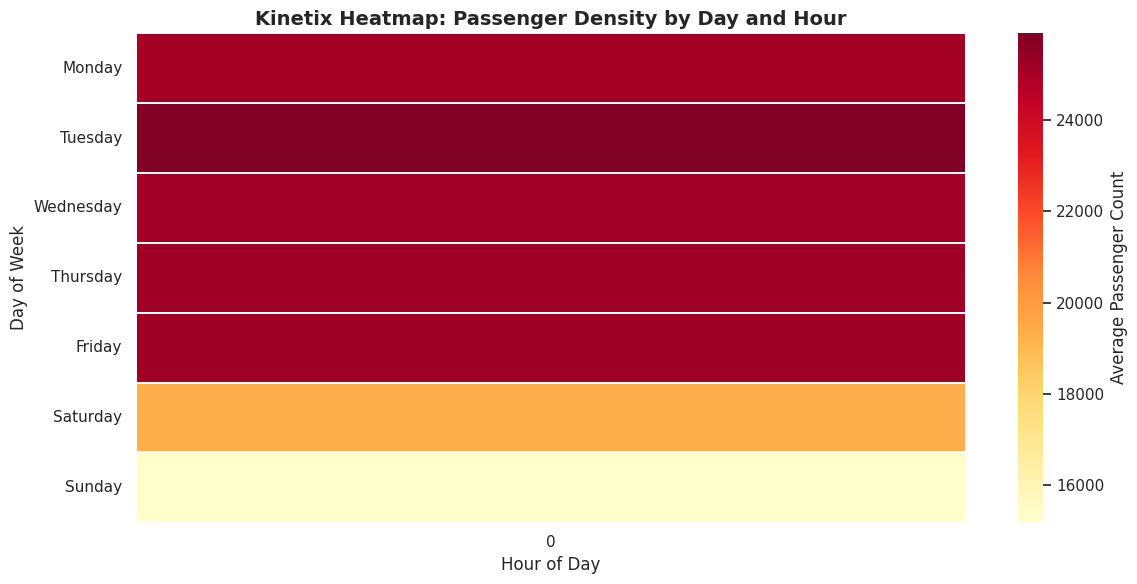

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if "df_clean" not in globals():
    raise ValueError("df_clean is not defined. Run the cleaning cell first.")

eda_df = df_clean.copy()

# Canonicalize expected columns for EDA
column_map = {}
for column in eda_df.columns:
    normalized = column.strip().lower()
    if ("date" in normalized) or ("tarix" in normalized):
        column_map[column] = "date"
    elif ("station" in normalized) or ("stansiya" in normalized):
        column_map[column] = "station_name"
    elif ("passenger" in normalized and "count" in normalized) or ("gediş" in normalized and "sayı" in normalized) or ("gedis" in normalized and "sayi" in normalized):
        column_map[column] = "passenger_count"

eda_df = eda_df.rename(columns=column_map)

required_cols = {"date", "station_name", "passenger_count"}
missing_required = required_cols.difference(eda_df.columns)
if missing_required:
    raise ValueError(f"Missing required columns for EDA: {sorted(missing_required)}")

eda_df["date"] = pd.to_datetime(eda_df["date"], errors="coerce")
eda_df["station_name"] = eda_df["station_name"].astype("string").str.strip()
eda_df["passenger_count"] = pd.to_numeric(eda_df["passenger_count"], errors="coerce")
eda_df = eda_df.dropna(subset=["date", "station_name", "passenger_count"]).copy()

# Helpful temporal columns
eda_df["hour_of_day"] = eda_df["date"].dt.hour
eda_df["day_of_week"] = eda_df["date"].dt.dayofweek
eda_df["day_name"] = eda_df["date"].dt.day_name()
eda_df["month"] = eda_df["date"].dt.month
eda_df["date_only"] = eda_df["date"].dt.date

# 1) Basic Data Profiling & Cleaning Check
print("=" * 80)
print("1) BASIC DATA PROFILING & CLEANING CHECK")
print("=" * 80)
print("\nStatistical summary of passenger_count:")
print(eda_df[["passenger_count"]].describe())

print("\nMissing values per column:")
print(eda_df.isna().sum())

daytime_mask = eda_df["hour_of_day"].between(6, 22, inclusive="both")
zero_daytime = eda_df[daytime_mask & (eda_df["passenger_count"] == 0)]

q1 = eda_df["passenger_count"].quantile(0.25)
q3 = eda_df["passenger_count"].quantile(0.75)
iqr = q3 - q1
high_outlier_threshold = q3 + 3 * iqr
high_spikes = eda_df[eda_df["passenger_count"] > high_outlier_threshold]

print(f"\nPotential outliers - zero daytime counts: {len(zero_daytime)}")
if not zero_daytime.empty:
    print(zero_daytime[["date", "station_name", "passenger_count"]].head(10))

print(f"\nPotential outliers - high spikes (>{high_outlier_threshold:,.2f}): {len(high_spikes)}")
if not high_spikes.empty:
    print(high_spikes[["date", "station_name", "passenger_count"]].sort_values("passenger_count", ascending=False).head(10))

# 2) The Big Picture (Macro Trend)
daily_total = (
    eda_df.groupby("date_only", as_index=False)["passenger_count"]
    .sum()
    .rename(columns={"passenger_count": "total_daily_passengers"})
)
daily_total["date_only"] = pd.to_datetime(daily_total["date_only"])
daily_total = daily_total.sort_values("date_only")
daily_total["rolling_7d_avg"] = daily_total["total_daily_passengers"].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(daily_total["date_only"], daily_total["total_daily_passengers"], label="Daily Total", linewidth=1.8)
plt.plot(daily_total["date_only"], daily_total["rolling_7d_avg"], label="7-Day Rolling Average", linewidth=2.5, color="crimson")
plt.title("Baku Metro: Total Daily Passenger Flow Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Total Passengers")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Seasonality Analysis (Micro Trends)
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_by_dow = (
    eda_df.groupby("day_name", as_index=False)["passenger_count"]
    .mean()
    .rename(columns={"passenger_count": "avg_passenger_count"})
)
avg_by_dow["day_name"] = pd.Categorical(avg_by_dow["day_name"], categories=dow_order, ordered=True)
avg_by_dow = avg_by_dow.sort_values("day_name")

avg_by_month = (
    eda_df.groupby("month", as_index=False)["passenger_count"]
    .mean()
    .rename(columns={"passenger_count": "avg_passenger_count"})
)
month_order = list(range(1, 13))
avg_by_month["month"] = pd.Categorical(avg_by_month["month"], categories=month_order, ordered=True)
avg_by_month = avg_by_month.sort_values("month")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=avg_by_dow, x="day_name", y="avg_passenger_count", palette="Blues_d", ax=axes[0])
axes[0].set_title("Average Passenger Density by Day of Week", fontweight="bold")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Average Passenger Count")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=avg_by_month, x="month", y="avg_passenger_count", palette="viridis", ax=axes[1])
axes[1].set_title("Average Passenger Count by Month", fontweight="bold")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average Passenger Count")
axes[1].set_xticks(range(0, 12))
axes[1].set_xticklabels(month_order)

fig.suptitle("Baku Metro Seasonality Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# 4) Spatial Analysis (Station-Level Insights)
station_avg = (
    eda_df.groupby("station_name", as_index=False)["passenger_count"]
    .mean()
    .rename(columns={"passenger_count": "avg_passenger_count"})
)

top_10 = station_avg.nlargest(10, "avg_passenger_count").assign(group="Top 10 Busiest")
bottom_10 = station_avg.nsmallest(10, "avg_passenger_count").assign(group="Bottom 10 Least Busy")
station_compare = pd.concat([top_10, bottom_10], ignore_index=True).sort_values("avg_passenger_count", ascending=True)

plt.figure(figsize=(12, 6))
palette = station_compare["group"].map({"Top 10 Busiest": "#d7301f", "Bottom 10 Least Busy": "#3182bd"})
plt.barh(station_compare["station_name"], station_compare["avg_passenger_count"] , color=palette)
plt.title("Baku Metro: Station Traffic Comparison (Most vs. Least Crowded)", fontsize=14, fontweight="bold")
plt.xlabel("Average Passenger Count")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

# 5) Density Heatmap (Time vs. Day)
heatmap_df = (
    eda_df.groupby(["day_name", "hour_of_day"], as_index=False)["passenger_count"]
    .mean()
    .rename(columns={"passenger_count": "avg_passenger_count"})
)
heatmap_df["day_name"] = pd.Categorical(heatmap_df["day_name"], categories=dow_order, ordered=True)
heatmap_df = heatmap_df.sort_values(["day_name", "hour_of_day"])
pivot_table = heatmap_df.pivot(index="day_name", columns="hour_of_day", values="avg_passenger_count")

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap="YlOrRd", linewidths=0.2, cbar_kws={"label": "Average Passenger Count"})
plt.title("Kinetix Heatmap: Passenger Density by Day and Hour", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

1) BASIC DATA PROFILING & CLEANING CHECK

Statistical summary of passenger_count:
       passenger_count
count      9855.000000
mean      23014.019990
std       17673.697162
min         182.000000
25%        7477.500000
50%       20899.000000
75%       32935.000000
max       77392.000000

Missing values per column:
date               0
station_name       0
passenger_count    0
hour_of_day        0
day_of_week        0
day_name           0
month              0
date_only          0
dtype: int64

Potential outliers - zero daytime counts: 0

Potential outliers - high spikes (>109,307.50): 0


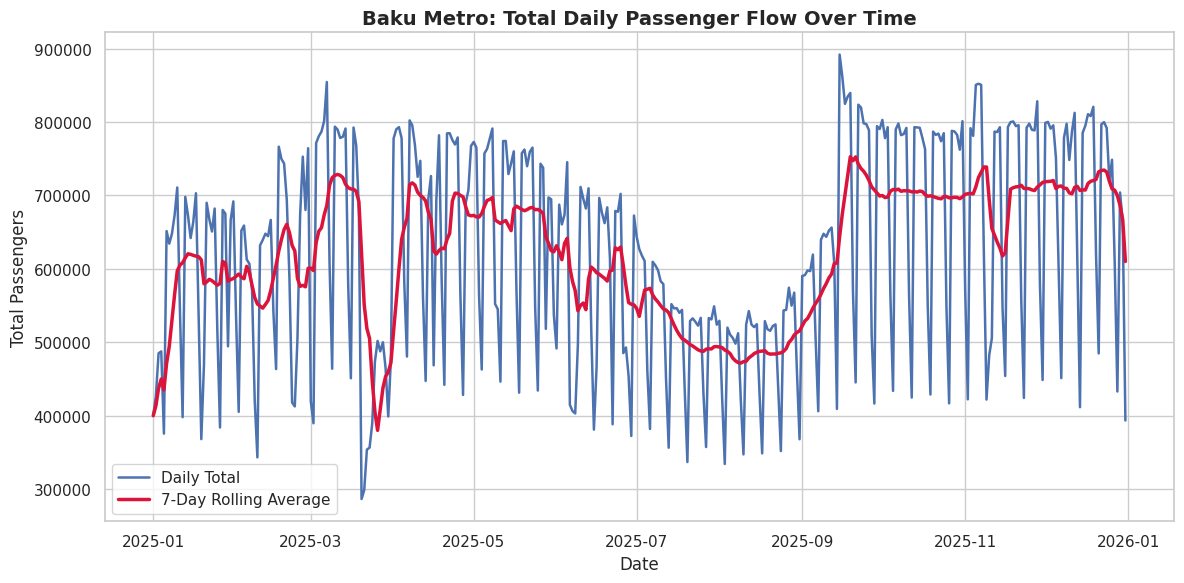

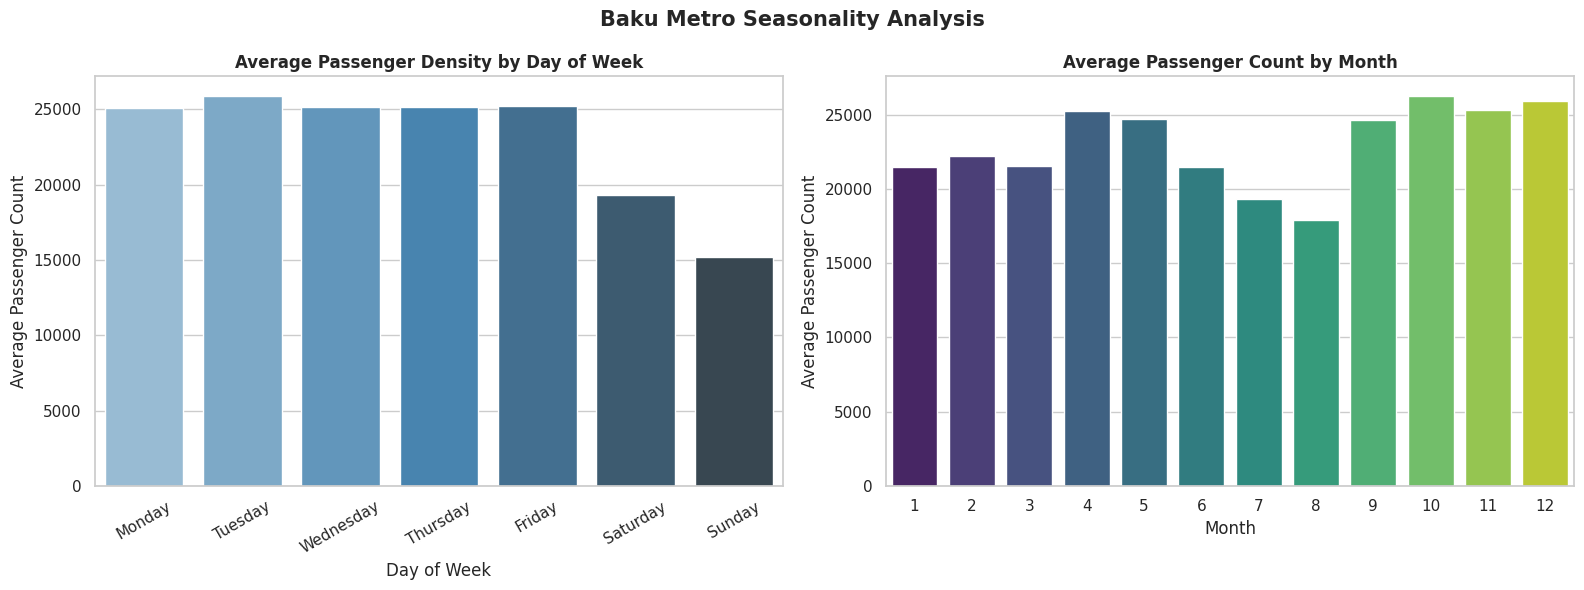

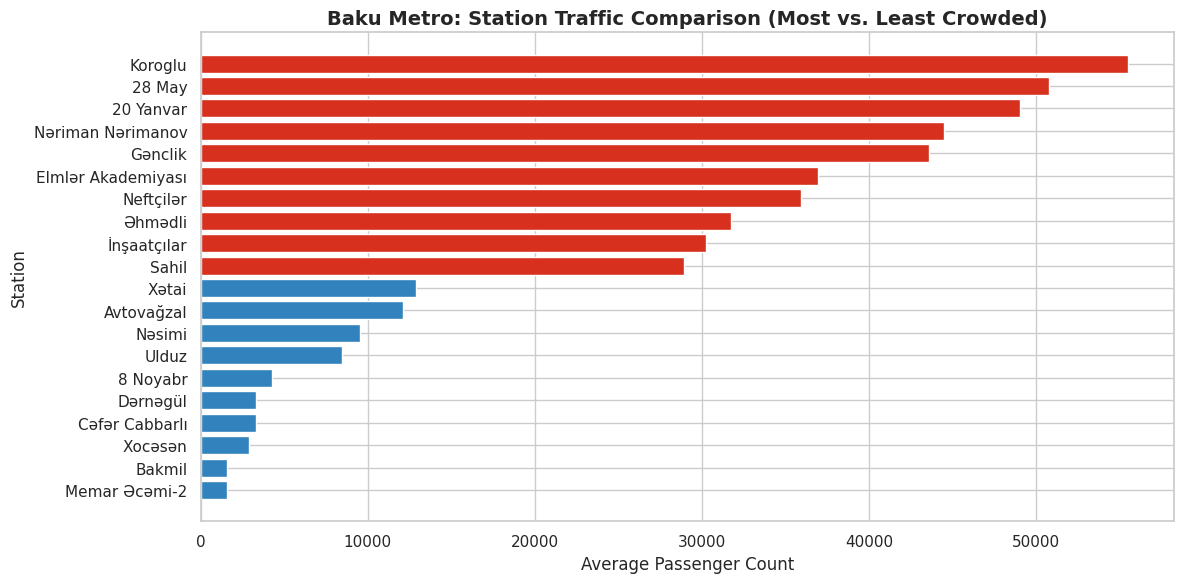

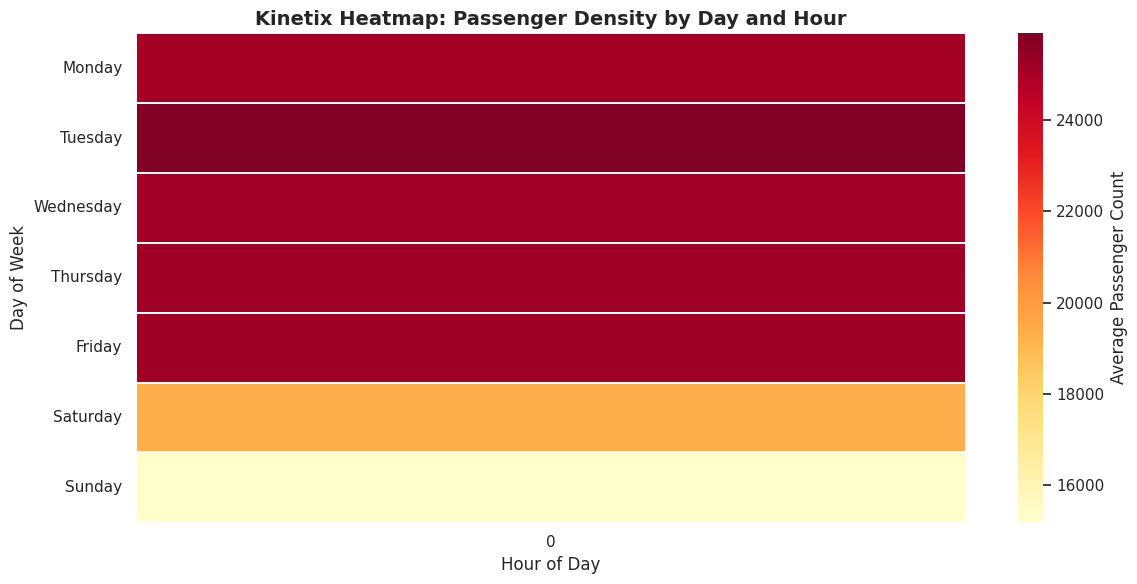

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if "df_clean" not in globals():
    raise ValueError("df_clean is not defined. Run the cleaning cell first.")

eda_df = df_clean.copy()

# Canonicalize expected columns for EDA
column_map = {}
for column in eda_df.columns:
    normalized = column.strip().lower()
    if ("date" in normalized) or ("tarix" in normalized):
        column_map[column] = "date"
    elif ("station" in normalized) or ("stansiya" in normalized):
        column_map[column] = "station_name"
    elif ("passenger" in normalized and "count" in normalized) or ("gediş" in normalized and "sayı" in normalized) or ("gedis" in normalized and "sayi" in normalized):
        column_map[column] = "passenger_count"

eda_df = eda_df.rename(columns=column_map)

required_cols = {"date", "station_name", "passenger_count"}
missing_required = required_cols.difference(eda_df.columns)
if missing_required:
    raise ValueError(f"Missing required columns for EDA: {sorted(missing_required)}")

eda_df["date"] = pd.to_datetime(eda_df["date"], errors="coerce")
eda_df["station_name"] = eda_df["station_name"].astype("string").str.strip()
eda_df["passenger_count"] = pd.to_numeric(eda_df["passenger_count"], errors="coerce")
eda_df = eda_df.dropna(subset=["date", "station_name", "passenger_count"]).copy()

# Helpful temporal columns
eda_df["hour_of_day"] = eda_df["date"].dt.hour
eda_df["day_of_week"] = eda_df["date"].dt.dayofweek
eda_df["day_name"] = eda_df["date"].dt.day_name()
eda_df["month"] = eda_df["date"].dt.month
eda_df["date_only"] = eda_df["date"].dt.date

# 1) Basic Data Profiling & Cleaning Check
print("=" * 80)
print("1) BASIC DATA PROFILING & CLEANING CHECK")
print("=" * 80)
print("\nStatistical summary of passenger_count:")
print(eda_df[["passenger_count"]].describe())

print("\nMissing values per column:")
print(eda_df.isna().sum())

daytime_mask = eda_df["hour_of_day"].between(6, 22, inclusive="both")
zero_daytime = eda_df[daytime_mask & (eda_df["passenger_count"] == 0)]

q1 = eda_df["passenger_count"].quantile(0.25)
q3 = eda_df["passenger_count"].quantile(0.75)
iqr = q3 - q1
high_outlier_threshold = q3 + 3 * iqr
high_spikes = eda_df[eda_df["passenger_count"] > high_outlier_threshold]

print(f"\nPotential outliers - zero daytime counts: {len(zero_daytime)}")
if not zero_daytime.empty:
    print(zero_daytime[["date", "station_name", "passenger_count"]].head(10))

print(f"\nPotential outliers - high spikes (>{high_outlier_threshold:,.2f}): {len(high_spikes)}")
if not high_spikes.empty:
    print(high_spikes[["date", "station_name", "passenger_count"]].sort_values("passenger_count", ascending=False).head(10))

# 2) The Big Picture (Macro Trend)
daily_total = (
    eda_df.groupby("date_only", as_index=False)["passenger_count"]
    .sum()
    .rename(columns={"passenger_count": "total_daily_passengers"})
)
daily_total["date_only"] = pd.to_datetime(daily_total["date_only"])
daily_total = daily_total.sort_values("date_only")
daily_total["rolling_7d_avg"] = daily_total["total_daily_passengers"].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(daily_total["date_only"], daily_total["total_daily_passengers"], label="Daily Total", linewidth=1.8)
plt.plot(daily_total["date_only"], daily_total["rolling_7d_avg"], label="7-Day Rolling Average", linewidth=2.5, color="crimson")
plt.title("Baku Metro: Total Daily Passenger Flow Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Total Passengers")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Seasonality Analysis (Micro Trends)
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_by_dow = (
    eda_df.groupby("day_name", as_index=False)["passenger_count"]
    .mean()
    .rename(columns={"passenger_count": "avg_passenger_count"})
)
avg_by_dow["day_name"] = pd.Categorical(avg_by_dow["day_name"], categories=dow_order, ordered=True)
avg_by_dow = avg_by_dow.sort_values("day_name")

avg_by_month = (
    eda_df.groupby("month", as_index=False)["passenger_count"]
    .mean()
    .rename(columns={"passenger_count": "avg_passenger_count"})
)
month_order = list(range(1, 13))
avg_by_month["month"] = pd.Categorical(avg_by_month["month"], categories=month_order, ordered=True)
avg_by_month = avg_by_month.sort_values("month")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DÜZƏLİŞ: hue="day_name" və legend=False əlavə edildi
sns.barplot(data=avg_by_dow, x="day_name", y="avg_passenger_count", hue="day_name", palette="Blues_d", legend=False, ax=axes[0])
axes[0].set_title("Average Passenger Density by Day of Week", fontweight="bold")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Average Passenger Count")
axes[0].tick_params(axis="x", rotation=30)

# DÜZƏLİŞ: hue="month" və legend=False əlavə edildi
sns.barplot(data=avg_by_month, x="month", y="avg_passenger_count", hue="month", palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Average Passenger Count by Month", fontweight="bold")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average Passenger Count")
axes[1].set_xticks(range(0, 12))
axes[1].set_xticklabels(month_order)

fig.suptitle("Baku Metro Seasonality Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# 4) Spatial Analysis (Station-Level Insights)
station_avg = (
    eda_df.groupby("station_name", as_index=False)["passenger_count"]
    .mean()
    .rename(columns={"passenger_count": "avg_passenger_count"})
)

top_10 = station_avg.nlargest(10, "avg_passenger_count").assign(group="Top 10 Busiest")
bottom_10 = station_avg.nsmallest(10, "avg_passenger_count").assign(group="Bottom 10 Least Busy")
station_compare = pd.concat([top_10, bottom_10], ignore_index=True).sort_values("avg_passenger_count", ascending=True)

plt.figure(figsize=(12, 6))
palette = station_compare["group"].map({"Top 10 Busiest": "#d7301f", "Bottom 10 Least Busy": "#3182bd"})
plt.barh(station_compare["station_name"], station_compare["avg_passenger_count"] , color=palette)
plt.title("Baku Metro: Station Traffic Comparison (Most vs. Least Crowded)", fontsize=14, fontweight="bold")
plt.xlabel("Average Passenger Count")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

# 5) Density Heatmap (Time vs. Day)
heatmap_df = (
    eda_df.groupby(["day_name", "hour_of_day"], as_index=False)["passenger_count"]
    .mean()
    .rename(columns={"passenger_count": "avg_passenger_count"})
)
heatmap_df["day_name"] = pd.Categorical(heatmap_df["day_name"], categories=dow_order, ordered=True)
heatmap_df = heatmap_df.sort_values(["day_name", "hour_of_day"])
pivot_table = heatmap_df.pivot(index="day_name", columns="hour_of_day", values="avg_passenger_count")

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap="YlOrRd", linewidths=0.2, cbar_kws={"label": "Average Passenger Count"})
plt.title("Kinetix Heatmap: Passenger Density by Day and Hour", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

In [13]:
import os
import json
import joblib
from datetime import datetime

xgb_model_obj = globals().get("xgb_model")
X_train_obj = globals().get("X_train")
rmse_obj = globals().get("rmse")

missing_objects = []
if xgb_model_obj is None:
    missing_objects.append("xgb_model")
if X_train_obj is None:
    missing_objects.append("X_train")
if rmse_obj is None:
    missing_objects.append("rmse")

if missing_objects:
    print(f"Skipping model artifact save. Missing required objects: {missing_objects}")
    print("Run model training and evaluation cells first, then re-run this cell.")
else:
    # Step 1: Directory Management (Safety First)
    MODEL_DIR = "models/"
    if not os.path.exists(MODEL_DIR):
        os.makedirs(MODEL_DIR)

    # File paths
    model_path = os.path.join(MODEL_DIR, "kinetix_xgboost_v1.joblib")
    schema_path = os.path.join(MODEL_DIR, "feature_schema.json")
    metadata_path = os.path.join(MODEL_DIR, "model_metadata.json")

    # Step 2: Serialize the XGBoost Model
    # joblib is preferred for scikit-learn compatible pipelines/models; native XGBoost .json saving is also possible.
    joblib.dump(xgb_model_obj, model_path)

    # Step 3: Save the Feature Schema (Crucial for Inference)
    feature_schema = X_train_obj.columns.tolist()
    with open(schema_path, "w", encoding="utf-8") as schema_file:
        json.dump(feature_schema, schema_file, indent=4, ensure_ascii=False)

    # Step 4: Save Model Metadata (Pro-level Logging)
    metadata = {
        "model_name": "Kinetix Baku Metro Density Predictor",
        "version": "1.0",
        "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "rmse_score": round(float(rmse_obj), 2),
    }
    with open(metadata_path, "w", encoding="utf-8") as metadata_file:
        json.dump(metadata, metadata_file, indent=4, ensure_ascii=False)

    # Step 5: Confirmation Output
    print("✅ Kinetix model artifacts saved successfully!")
    print(f"- Model file   : {model_path}")
    print(f"- Schema file  : {schema_path}")
    print(f"- Metadata file: {metadata_path}")

✅ Kinetix model artifacts saved successfully!
- Model file   : models/kinetix_xgboost_v1.joblib
- Schema file  : models/feature_schema.json
- Metadata file: models/model_metadata.json


In [14]:
import os
import json
import joblib
from datetime import datetime
import pandas as pd

class KinetixPredictor:
    def __init__(self, model_dir="models/"):
        self.model_dir = model_dir
        model_path = os.path.join(self.model_dir, "kinetix_xgboost_v1.joblib")
        schema_path = os.path.join(self.model_dir, "feature_schema.json")

        try:
            self.model = joblib.load(model_path)
        except FileNotFoundError as error:
            raise FileNotFoundError(
                f"Model file not found at '{model_path}'. Train and serialize the model first."
            ) from error

        try:
            with open(schema_path, "r", encoding="utf-8") as schema_file:
                self.features = json.load(schema_file)
        except FileNotFoundError as error:
            raise FileNotFoundError(
                f"Feature schema not found at '{schema_path}'. Train and serialize schema first."
            ) from error

        if not isinstance(self.features, list) or not self.features:
            raise ValueError("Loaded feature schema is invalid or empty.")

    @staticmethod
    def _normalize_text(value: str) -> str:
        return "".join(ch.lower() for ch in value if ch.isalnum())

    @staticmethod
    def _is_holiday_az(target_date: datetime) -> bool:
        major_holidays = {
            "2024-01-01", "2024-01-02", "2024-03-20", "2024-03-21", "2024-03-22", "2024-03-23", "2024-03-24",
            "2024-03-08", "2024-05-09", "2024-05-28", "2024-06-15", "2024-06-26", "2024-11-08", "2024-11-09", "2024-12-31",
            "2025-01-01", "2025-01-02", "2025-03-20", "2025-03-21", "2025-03-22", "2025-03-23", "2025-03-24",
            "2025-03-08", "2025-05-09", "2025-05-28", "2025-06-15", "2025-06-26", "2025-11-08", "2025-11-09", "2025-12-31",
        }
        return target_date.strftime("%Y-%m-%d") in major_holidays

    @staticmethod
    def _is_academic_season(target_date: datetime) -> bool:
        month = target_date.month
        day = target_date.day
        in_season = (month > 9 or (month == 9 and day >= 15)) or (month < 6 or (month == 5 and day <= 31))
        return in_season and month != 1

    def _prepare_features(self, target_date: str, target_time: str, station_name: str) -> pd.DataFrame:
        request_dt = datetime.strptime(f"{target_date} {target_time}", "%Y-%m-%d %H:%M")

        hour = request_dt.hour
        day_of_week = request_dt.weekday()
        month = request_dt.month
        minute_of_day = request_dt.hour * 60 + request_dt.minute

        is_weekend = day_of_week >= 5
        is_rush_hour = (450 <= minute_of_day <= 570) or (1050 <= minute_of_day <= 1170)
        is_academic_season = self._is_academic_season(request_dt)
        is_holiday_az = self._is_holiday_az(request_dt)

        normalized_station = self._normalize_text(station_name)
        transfer_hub_stations = {self._normalize_text("28 May"), self._normalize_text("Memar Ajami")}
        student_hub_stations = {self._normalize_text("Elmler Akademiyasi"), self._normalize_text("Genclik")}

        is_transfer_hub = normalized_station in transfer_hub_stations
        is_student_hub = normalized_station in student_hub_stations

        # Schema alignment: exact training matrix column order
        aligned_df = pd.DataFrame([[0] * len(self.features)], columns=self.features)

        computed_features = {
            "hour": hour,
            "day_of_week": day_of_week,
            "month": month,
            "is_weekend": int(is_weekend),
            "is_rush_hour": int(is_rush_hour),
            "is_academic_season": int(is_academic_season),
            "is_holiday_az": int(is_holiday_az),
            "is_transfer_hub": int(is_transfer_hub),
            "is_student_hub": int(is_student_hub),
        }

        for feature_name, feature_value in computed_features.items():
            if feature_name in aligned_df.columns:
                aligned_df.at[0, feature_name] = feature_value

        # One-hot station alignment
        direct_station_col = f"station_{station_name}"
        if direct_station_col in aligned_df.columns:
            aligned_df.at[0, direct_station_col] = 1
        else:
            normalized_target_station_col = self._normalize_text(direct_station_col)
            for col in aligned_df.columns:
                if col.startswith("station_") and self._normalize_text(col) == normalized_target_station_col:
                    aligned_df.at[0, col] = 1
                    break

        return aligned_df

    def predict(self, target_date: str, target_time: str, station_name: str, station_capacity: int = 5000) -> dict:
        inference_df = self._prepare_features(target_date, target_time, station_name)
        raw_prediction = float(self.model.predict(inference_df)[0])
        predicted_passengers = max(0, int(raw_prediction))

        occupancy_percentage = (predicted_passengers / station_capacity) * 100 if station_capacity > 0 else 0.0

        if occupancy_percentage < 40:
            comfort_status = "🟢 Comfortable (Seats likely available)"
        elif occupancy_percentage <= 75:
            comfort_status = "🟡 Moderate (Standing room only)"
        else:
            comfort_status = "🔴 Crowded (Expect delays, consider waiting 15 mins)"

        return {
            "request_datetime": f"{target_date} {target_time}",
            "station": station_name,
            "predicted_passengers": predicted_passengers,
            "occupancy_percentage": round(occupancy_percentage, 1),
            "comfort_status": comfort_status,
        }

# Example usage
kinetix_predictor = KinetixPredictor(model_dir="models/")
sample_prediction = kinetix_predictor.predict(
    target_date="2026-02-15",
    target_time="08:30",
    station_name="28-May",
    station_capacity=5000,
 )
print(sample_prediction)

{'request_datetime': '2026-02-15 08:30', 'station': '28-May', 'predicted_passengers': 1307, 'occupancy_percentage': 26.1, 'comfort_status': '🟢 Comfortable (Seats likely available)'}


In [16]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score

y_test_obj = globals().get("y_test")
y_pred_obj = globals().get("y_pred")

missing_objects = []
if y_test_obj is None:
    missing_objects.append("y_test")
if y_pred_obj is None:
    missing_objects.append("y_pred")

if missing_objects:
    print(f"Skipping final accuracy report. Missing required objects: {missing_objects}")
    print("Run model training cell first, then re-run this cell.")
else:
    # Yoxlama məlumatları (test data) üzərində MAPE hesablayırıq
    # Qeyd: MAPE 0 ilə 1 arasında (və ya % olaraq) xəta payını göstərir
    mape = mean_absolute_percentage_error(y_test_obj, y_pred_obj)

    # Xəta faizini 100-dən çıxaraq "Dəqiqlik Faizi"ni (Accuracy) tapırıq
    business_accuracy = (1 - mape) * 100

    # R2 Score (Modelin vəziyyəti izah etmə gücü)
    r2 = r2_score(y_test_obj, y_pred_obj) * 100

    print("KINETIX MODELİNİN DƏQİQLİK GÖSTƏRİCİLƏRİ:")
    print("-" * 50)
    print(f"Dəqiqlik (Business Accuracy): {business_accuracy:.2f}%")
    print(f"R² Score (Məlumatı anlama gücü): {r2:.2f}%")
    print(f" Xəta Payı (MAPE): {mape * 100:.2f}%")
    print("-" * 50)

    # Təqdimat (Pitching) üçün kiçik bir izah şablonu:
    print(f"Pitching üçün cümlə: 'Kinetix Süni İntellekt mühərriki Bakı metrosundakı sərnişin sıxlığını {business_accuracy:.1f}% dəqiqliklə proqnozlaşdırır.'")

KINETIX MODELİNİN DƏQİQLİK GÖSTƏRİCİLƏRİ:
--------------------------------------------------
Dəqiqlik (Business Accuracy): 93.49%
R² Score (Məlumatı anlama gücü): 98.59%
 Xəta Payı (MAPE): 6.51%
--------------------------------------------------
Pitching üçün cümlə: 'Kinetix Süni İntellekt mühərriki Bakı metrosundakı sərnişin sıxlığını 93.5% dəqiqliklə proqnozlaşdırır.'


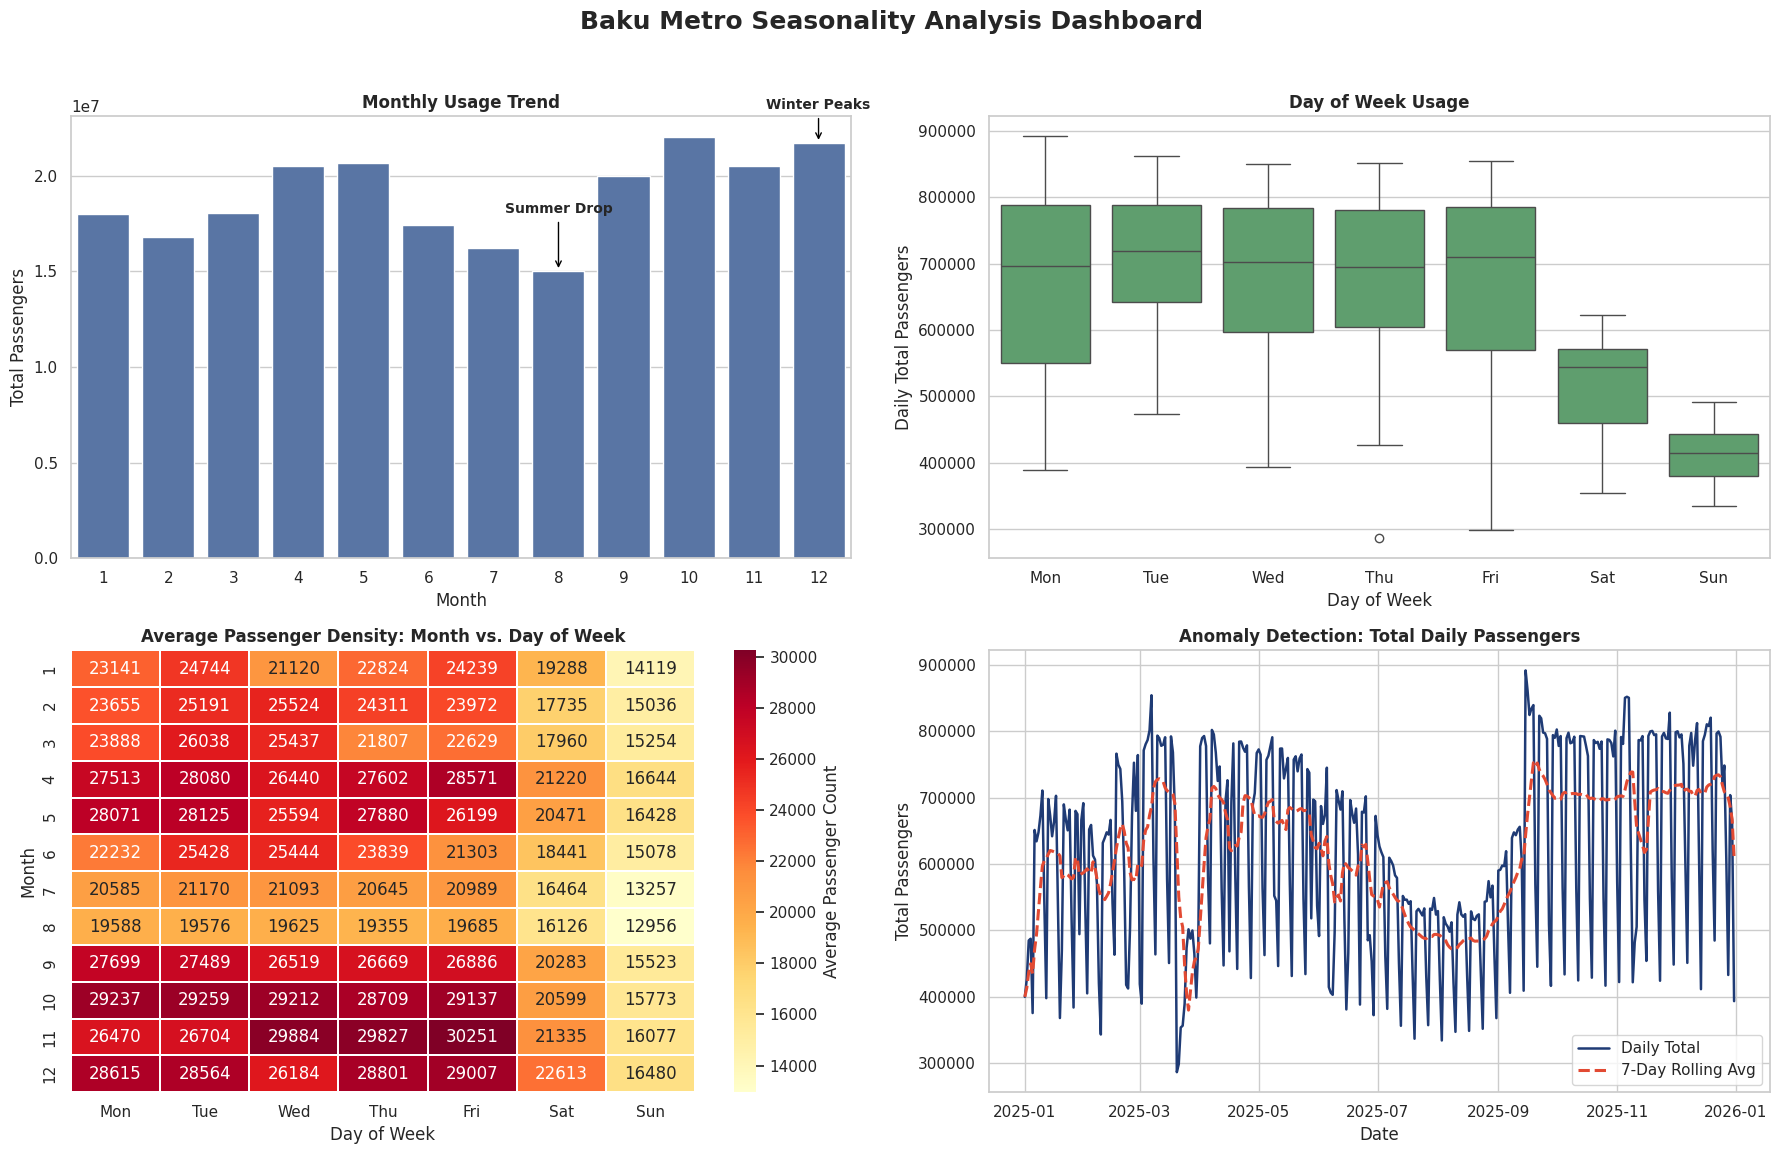

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if "df_clean" not in globals():
    raise ValueError("df_clean is not defined. Run the cleaning cell first.")

dashboard_df = df_clean.copy()

# Canonicalize columns
column_map = {}
for column in dashboard_df.columns:
    normalized = column.strip().lower()
    if ("date" in normalized) or ("tarix" in normalized):
        column_map[column] = "date"
    elif ("station" in normalized) or ("stansiya" in normalized):
        column_map[column] = "station_name"
    elif ("passenger" in normalized and "count" in normalized) or ("gediş" in normalized and "sayı" in normalized) or ("gedis" in normalized and "sayi" in normalized):
        column_map[column] = "passenger_count"

dashboard_df = dashboard_df.rename(columns=column_map)
required_cols = {"date", "station_name", "passenger_count"}
missing_cols = required_cols.difference(dashboard_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns for dashboard: {sorted(missing_cols)}")

dashboard_df["date"] = pd.to_datetime(dashboard_df["date"], errors="coerce")
dashboard_df["station_name"] = dashboard_df["station_name"].astype("string").str.strip()
dashboard_df["passenger_count"] = pd.to_numeric(dashboard_df["passenger_count"], errors="coerce")
dashboard_df = dashboard_df.dropna(subset=["date", "station_name", "passenger_count"]).copy()

dashboard_df["month"] = dashboard_df["date"].dt.month
dashboard_df["day_of_week"] = dashboard_df["date"].dt.dayofweek
dashboard_df["date_only"] = dashboard_df["date"].dt.normalize()

dow_name_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
dow_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Baku Metro Seasonality Analysis Dashboard", fontsize=18, fontweight="bold")

# 1) Top Left: Monthly Usage Trend (total passengers per month)
monthly_total = (
    dashboard_df.groupby("month", as_index=False)["passenger_count"]
    .sum()
    .rename(columns={"passenger_count": "total_passengers"})
)
month_template = pd.DataFrame({"month": list(range(1, 13))})
monthly_total = month_template.merge(monthly_total, on="month", how="left")
monthly_total["total_passengers"] = monthly_total["total_passengers"].fillna(0)

sns.barplot(data=monthly_total, x="month", y="total_passengers", color="#4C72B0", ax=axes[0, 0])
axes[0, 0].set_title("Monthly Usage Trend", fontweight="bold")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Total Passengers")
axes[0, 0].set_xticks(range(0, 12))
axes[0, 0].set_xticklabels(range(1, 13))

winter_months = [12, 1, 2]
summer_months = [6, 7, 8]
winter_data = monthly_total[monthly_total["month"].isin(winter_months)]
summer_data = monthly_total[monthly_total["month"].isin(summer_months)]

winter_peak_month = int(winter_data.loc[winter_data["total_passengers"].idxmax(), "month"])
winter_peak_value = float(winter_data["total_passengers"].max())
summer_drop_month = int(summer_data.loc[summer_data["total_passengers"].idxmin(), "month"])
summer_drop_value = float(summer_data["total_passengers"].min())

axes[0, 0].annotate(
    "Winter Peaks",
    xy=(winter_peak_month - 1, winter_peak_value),
    xytext=(winter_peak_month - 1, winter_peak_value * 1.08 if winter_peak_value > 0 else 1),
    arrowprops={"arrowstyle": "->", "color": "black"},
    ha="center",
    fontsize=10,
    fontweight="bold",
)
axes[0, 0].annotate(
    "Summer Drop",
    xy=(summer_drop_month - 1, summer_drop_value),
    xytext=(summer_drop_month - 1, summer_drop_value * 1.2 + 1),
    arrowprops={"arrowstyle": "->", "color": "black"},
    ha="center",
    fontsize=10,
    fontweight="bold",
)

# 2) Top Right: Day of Week Usage
daily_station = (
    dashboard_df.groupby(["date_only", "day_of_week"], as_index=False)["passenger_count"]
    .sum()
    .rename(columns={"passenger_count": "daily_total_passengers"})
)
daily_station["day_name"] = daily_station["day_of_week"].map(dow_name_map)
daily_station["day_name"] = pd.Categorical(daily_station["day_name"], categories=dow_order, ordered=True)

sns.boxplot(
    data=daily_station,
    x="day_name",
    y="daily_total_passengers",
    order=dow_order,
    color="#55A868",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Day of Week Usage", fontweight="bold")
axes[0, 1].set_xlabel("Day of Week")
axes[0, 1].set_ylabel("Daily Total Passengers")

# 3) Bottom Left: Month vs Day of Week Heatmap
month_dow_pivot = dashboard_df.pivot_table(
    index="month",
    columns="day_of_week",
    values="passenger_count",
    aggfunc="mean",
)
month_dow_pivot = month_dow_pivot.reindex(index=range(1, 13), columns=range(0, 7))
month_dow_pivot = month_dow_pivot.rename(columns=dow_name_map)

sns.heatmap(
    month_dow_pivot,
    ax=axes[1, 0],
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.2,
    cbar_kws={"label": "Average Passenger Count"},
)
axes[1, 0].set_title("Average Passenger Density: Month vs. Day of Week", fontweight="bold")
axes[1, 0].set_xlabel("Day of Week")
axes[1, 0].set_ylabel("Month")

# 4) Bottom Right: Anomaly Detection on Daily Totals
daily_total = (
    dashboard_df.groupby("date_only", as_index=False)["passenger_count"]
    .sum()
    .rename(columns={"passenger_count": "total_daily_passengers"})
    .sort_values("date_only")
)
daily_total["rolling_7d"] = daily_total["total_daily_passengers"].rolling(window=7, min_periods=1).mean()
daily_std = daily_total["total_daily_passengers"].std(ddof=0)
if daily_std == 0 or pd.isna(daily_std):
    daily_total["z_score"] = 0.0
else:
    daily_total["z_score"] = (daily_total["total_daily_passengers"] - daily_total["total_daily_passengers"].mean()) / daily_std
anomalies = daily_total[daily_total["z_score"].abs() >= 2.5].copy()

axes[1, 1].plot(
    daily_total["date_only"],
    daily_total["total_daily_passengers"],
    color="#1f3b75",
    linewidth=1.8,
    label="Daily Total",
)
axes[1, 1].plot(
    daily_total["date_only"],
    daily_total["rolling_7d"],
    color="#E24A33",
    linewidth=2.2,
    linestyle="--",
    label="7-Day Rolling Avg",
)
if not anomalies.empty:
    axes[1, 1].scatter(
        anomalies["date_only"],
        anomalies["total_daily_passengers"],
        color="red",
        s=50,
        label="Anomaly (|z|>=2.5)",
        zorder=3,
    )
axes[1, 1].set_title("Anomaly Detection: Total Daily Passengers", fontweight="bold")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Total Passengers")
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

Density summary:
count    9855.000000
mean        4.602804
std         3.534739
min         0.036400
25%         1.495500
50%         4.179800
75%         6.587000
max        15.478400
Name: density, dtype: float64
High-density event count: 8247 / 9855


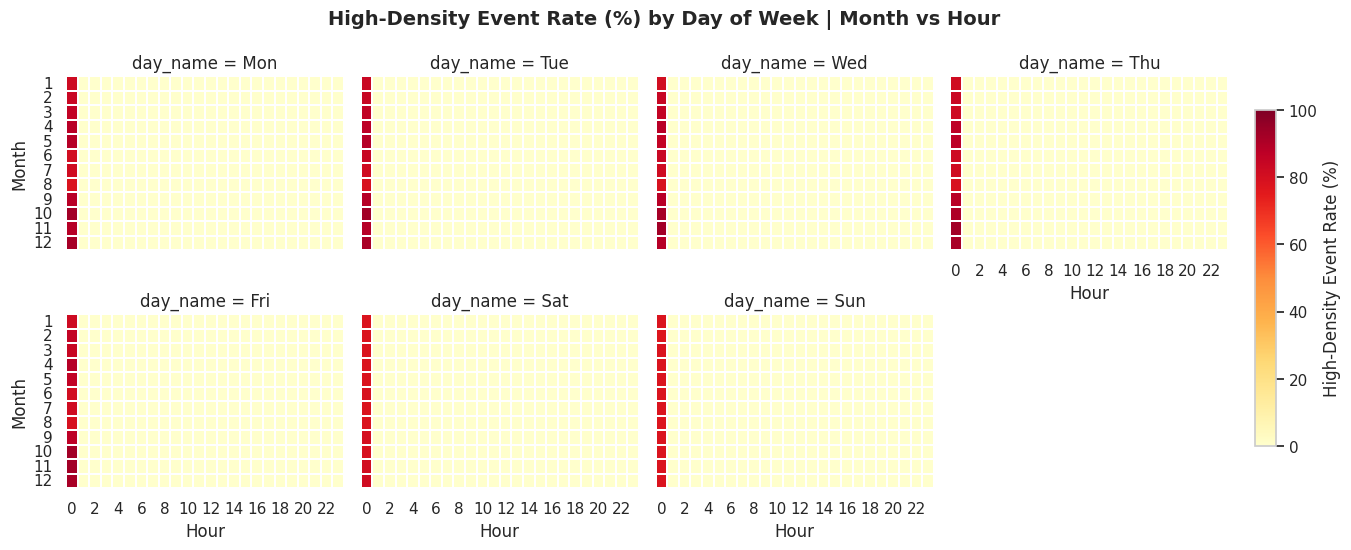

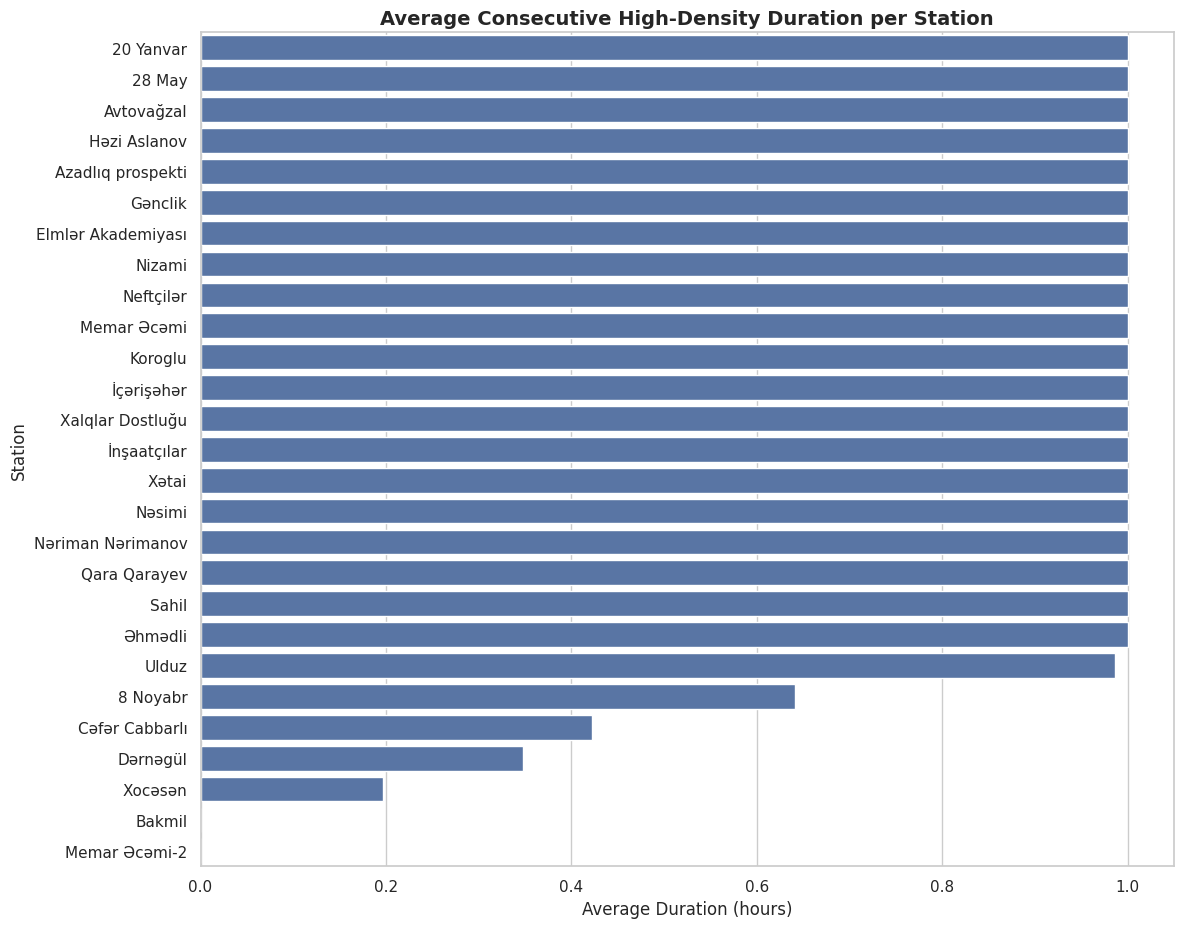

Top stations by average high-density duration:
          station_name  high_density_duration_hours
0            20 Yanvar                          1.0
1               28 May                          1.0
3           Avtovağzal                          1.0
10        Həzi Aslanov                          1.0
4    Azadlıq prospekti                          1.0
9              Gənclik                          1.0
8   Elmlər Akademiyası                          1.0
15              Nizami                          1.0
14           Neftçilər                          1.0
12         Memar Əcəmi                          1.0


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if "df_clean" not in globals():
    raise ValueError("df_clean is not defined. Run the cleaning cell first.")

# --- Canonicalize and prepare analysis dataframe ---
peak_df = df_clean.copy()
column_map = {}
for column in peak_df.columns:
    normalized = column.strip().lower()
    if ("date" in normalized) or ("tarix" in normalized):
        column_map[column] = "date"
    elif ("station" in normalized) or ("stansiya" in normalized):
        column_map[column] = "station_name"
    elif ("passenger" in normalized and "count" in normalized) or ("gediş" in normalized and "sayı" in normalized) or ("gedis" in normalized and "sayi" in normalized):
        column_map[column] = "passenger_count"

peak_df = peak_df.rename(columns=column_map)
required_cols = {"date", "station_name", "passenger_count"}
missing_cols = required_cols.difference(peak_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns for peak-density analysis: {sorted(missing_cols)}")

peak_df["date"] = pd.to_datetime(peak_df["date"], errors="coerce")
peak_df["station_name"] = peak_df["station_name"].astype("string").str.strip()
peak_df["passenger_count"] = pd.to_numeric(peak_df["passenger_count"], errors="coerce")
peak_df = peak_df.dropna(subset=["date", "station_name", "passenger_count"]).copy()

# Use existing hour if present; otherwise derive from date (daily-aggregated data will typically be 0)
if "hour" in peak_df.columns:
    peak_df["hour"] = pd.to_numeric(peak_df["hour"], errors="coerce").fillna(0).astype(int)
else:
    peak_df["hour"] = peak_df["date"].dt.hour.fillna(0).astype(int)

peak_df["month"] = peak_df["date"].dt.month
peak_df["day_of_week"] = peak_df["date"].dt.dayofweek
peak_df["date_only"] = peak_df["date"].dt.normalize()

# --- 1) Density and High Density Events ---
station_capacity = 5000
high_density_threshold = 0.75
count_threshold = station_capacity * high_density_threshold

peak_df["density"] = peak_df["passenger_count"] / station_capacity
peak_df["is_high_density"] = (peak_df["density"] > high_density_threshold) | (peak_df["passenger_count"] > count_threshold)

print("Density summary:")
print(peak_df["density"].describe())
print(f"High-density event count: {int(peak_df['is_high_density'].sum())} / {len(peak_df)}")

# --- 2) Faceted Heatmap: High-Density Event Rate by Weekday (month x hour) ---
dow_name_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
dow_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

heat_source = peak_df.copy()
heat_source["day_name"] = heat_source["day_of_week"].map(dow_name_map)

# Percentage of high-density events at each (day_name, month, hour)
heat_agg = (
    heat_source.groupby(["day_name", "month", "hour"], as_index=False)["is_high_density"]
    .mean()
    .rename(columns={"is_high_density": "high_density_rate"})
)
heat_agg["high_density_rate"] = heat_agg["high_density_rate"] * 100

# Build full month-hour template so missing combinations show as 0
month_hour_template = pd.MultiIndex.from_product([range(1, 13), range(24)], names=["month", "hour"]).to_frame(index=False)
heat_full = (
    pd.MultiIndex.from_product([dow_order], names=["day_name"]).to_frame(index=False)
    .merge(month_hour_template, how="cross")
    .merge(heat_agg, on=["day_name", "month", "hour"], how="left")
)
heat_full["high_density_rate"] = heat_full["high_density_rate"].fillna(0.0)

def facet_heatmap(data, **kwargs):
    ax = plt.gca()
    pivot = data.pivot(index="month", columns="hour", values="high_density_rate")
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="YlOrRd",
        vmin=0,
        vmax=100,
        cbar=False,
        linewidths=0.15,
        linecolor="white",
    )
    ax.set_xlabel("Hour")
    ax.set_ylabel("Month")

facet = sns.FacetGrid(
    heat_full,
    col="day_name",
    col_order=dow_order,
    col_wrap=4,
    height=2.8,
    aspect=1.2,
    sharex=True,
    sharey=True,
)
facet.map_dataframe(facet_heatmap)
facet.fig.subplots_adjust(top=0.86, right=0.92)
facet.fig.suptitle("High-Density Event Rate (%) by Day of Week | Month vs Hour", fontsize=14, fontweight="bold")

# Add shared colorbar
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(vmin=0, vmax=100))
sm.set_array([])
cax = facet.fig.add_axes([0.94, 0.2, 0.015, 0.6])
facet.fig.colorbar(sm, cax=cax, label="High-Density Event Rate (%)")

plt.show()

# --- 3) Average Consecutive High-Density Duration per Station per Day ---
duration_df = peak_df.sort_values(["station_name", "date_only", "hour"]).copy()

def compute_daily_high_density_duration(group: pd.DataFrame) -> float:
    high_hours = group.loc[group["is_high_density"], "hour"]
    if high_hours.empty:
        return 0.0
    return float(high_hours.max() - high_hours.min() + 1)

daily_duration = (
    duration_df.groupby(["station_name", "date_only"], as_index=False)
    .apply(lambda g: pd.Series({"high_density_duration_hours": compute_daily_high_density_duration(g)}), include_groups=False)
    .reset_index(drop=True)
)

avg_duration_by_station = (
    daily_duration.groupby("station_name", as_index=False)["high_density_duration_hours"]
    .mean()
    .sort_values("high_density_duration_hours", ascending=False)
)

plt.figure(figsize=(12, max(6, 0.35 * len(avg_duration_by_station))))
sns.barplot(
    data=avg_duration_by_station,
    x="high_density_duration_hours",
    y="station_name",
    color="#4C72B0",
)
plt.title("Average Consecutive High-Density Duration per Station", fontsize=14, fontweight="bold")
plt.xlabel("Average Duration (hours)")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

print("Top stations by average high-density duration:")
print(avg_duration_by_station.head(10))

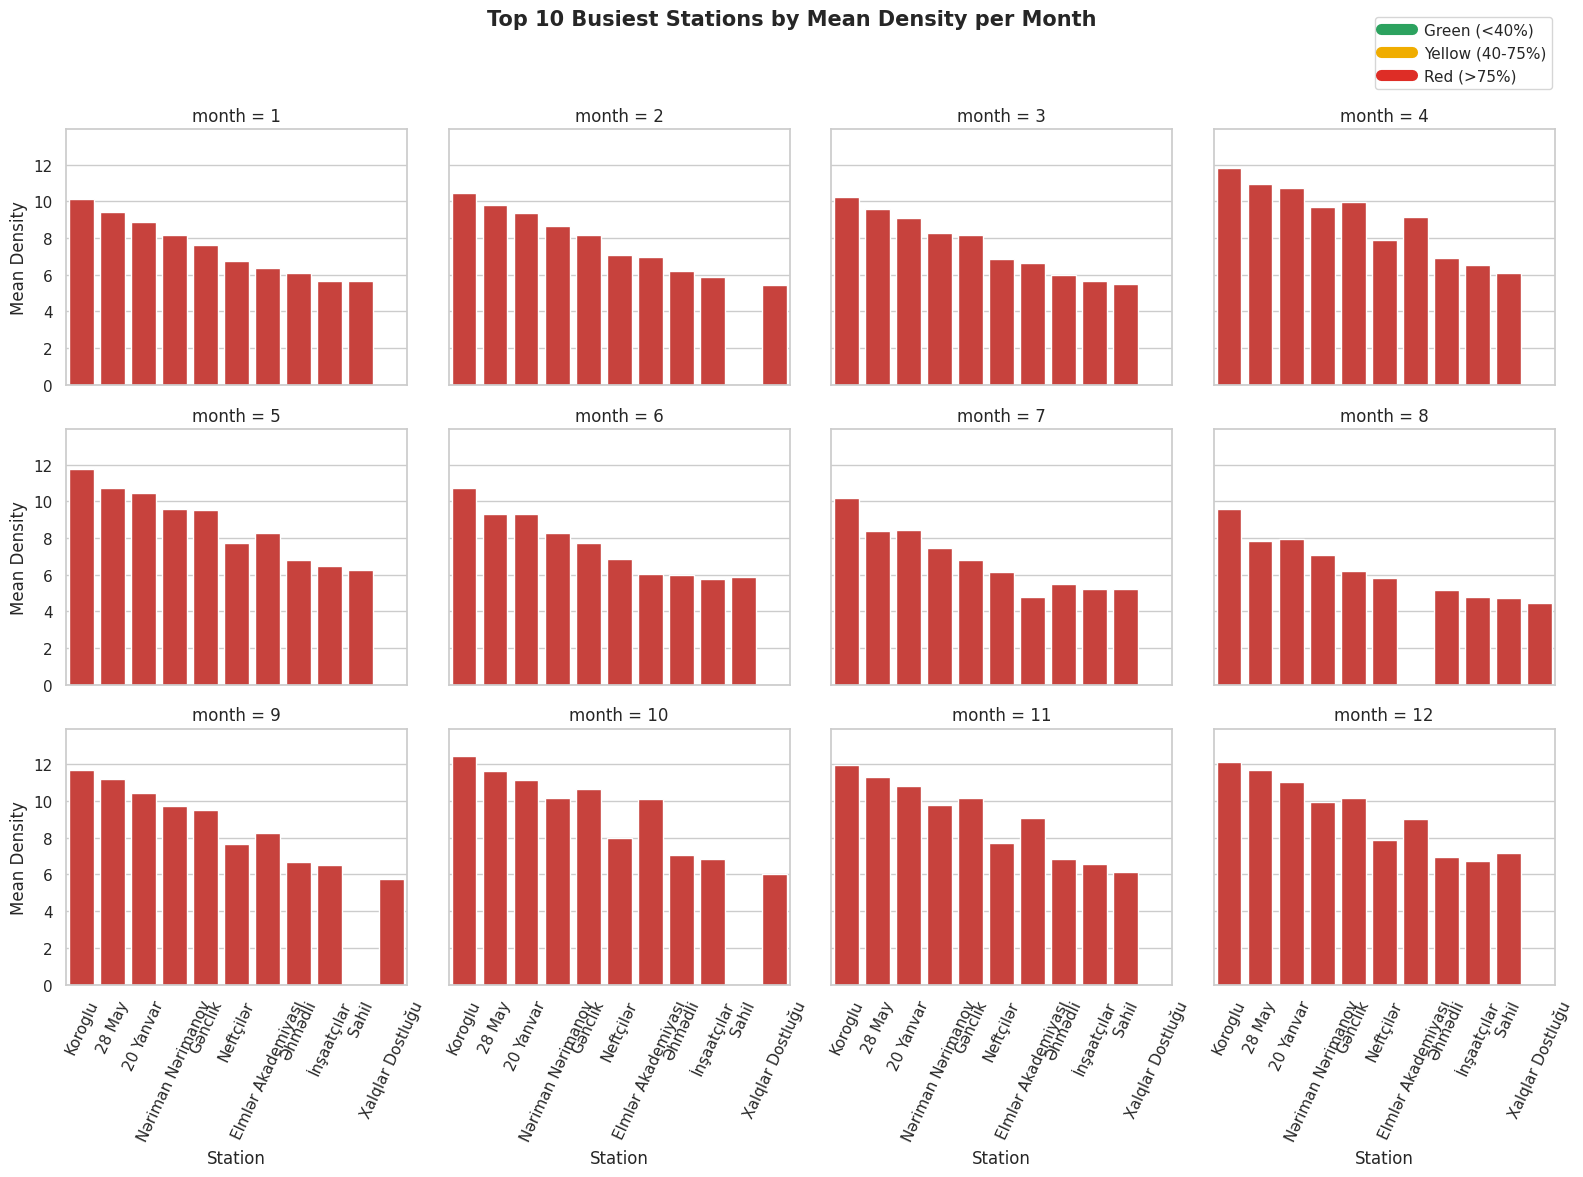

Payload meta:
{'station_capacity': 5000, 'density_formula': 'density = passenger_count / station_capacity', 'comfort_thresholds': {'Green': 'density < 0.40', 'Yellow': '0.40 <= density <= 0.75', 'Red': 'density > 0.75'}, 'top_n_stations_per_month': 10, 'months_included': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}

Sample month payload:
{'month': 1, 'top_stations': [{'month': 1, 'station_name': 'Koroglu', 'mean_density': 10.12623870967742, 'comfort_band': 'Red', 'density_percent': 1012.6238709677419}, {'month': 1, 'station_name': '28 May', 'mean_density': 9.396516129032257, 'comfort_band': 'Red', 'density_percent': 939.6516129032257}, {'month': 1, 'station_name': '20 Yanvar', 'mean_density': 8.896638709677418, 'comfort_band': 'Red', 'density_percent': 889.6638709677418}, {'month': 1, 'station_name': 'Nəriman Nərimanov', 'mean_density': 8.158406451612903, 'comfort_band': 'Red', 'density_percent': 815.8406451612902}, {'month': 1, 'station_name': 'Gənclik', 'mean_density': 7.637535483870968,

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def canonicalize_station_daily_dataframe(dataframe: pd.DataFrame) -> pd.DataFrame:
    canonical = dataframe.copy()
    column_map = {}
    for column in canonical.columns:
        normalized = column.strip().lower()
        if ("date" in normalized) or ("tarix" in normalized):
            column_map[column] = "date"
        elif ("station" in normalized) or ("stansiya" in normalized):
            column_map[column] = "station_name"
        elif ("passenger" in normalized and "count" in normalized) or ("gediş" in normalized and "sayı" in normalized) or ("gedis" in normalized and "sayi" in normalized):
            column_map[column] = "passenger_count"

    canonical = canonical.rename(columns=column_map)
    required_cols = {"date", "station_name", "passenger_count"}
    missing_cols = required_cols.difference(canonical.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

    canonical["date"] = pd.to_datetime(canonical["date"], errors="coerce")
    canonical["station_name"] = canonical["station_name"].astype("string").str.strip()
    canonical["passenger_count"] = pd.to_numeric(canonical["passenger_count"], errors="coerce")
    canonical = canonical.dropna(subset=["date", "station_name", "passenger_count"]).copy()
    canonical["month"] = canonical["date"].dt.month
    return canonical

def comfort_band_from_density(density_value: float) -> str:
    if density_value < 0.40:
        return "Green"
    if density_value <= 0.75:
        return "Yellow"
    return "Red"

def build_station_monthly_payload(dataframe: pd.DataFrame, station_capacity: int = 5000, top_n: int = 10) -> dict:
    prepared = canonicalize_station_daily_dataframe(dataframe)
    prepared["density"] = prepared["passenger_count"] / station_capacity

    station_month = (
        prepared.groupby(["month", "station_name"], as_index=False)["density"]
        .mean()
        .rename(columns={"density": "mean_density"})
    )
    station_month["comfort_band"] = station_month["mean_density"].map(comfort_band_from_density)
    station_month["density_percent"] = station_month["mean_density"] * 100

    top_by_month = (
        station_month.sort_values(["month", "mean_density"], ascending=[True, False])
        .groupby("month", as_index=False, group_keys=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    months_payload = []
    for month_value, group in top_by_month.groupby("month", sort=True):
        month_records = group.sort_values("mean_density", ascending=False).to_dict(orient="records")
        months_payload.append({
            "month": int(month_value),
            "top_stations": month_records,
        })

    payload = {
        "meta": {
            "station_capacity": int(station_capacity),
            "density_formula": "density = passenger_count / station_capacity",
            "comfort_thresholds": {
                "Green": "density < 0.40",
                "Yellow": "0.40 <= density <= 0.75",
                "Red": "density > 0.75",
            },
            "top_n_stations_per_month": int(top_n),
            "months_included": sorted([int(value) for value in top_by_month["month"].unique().tolist()]),
        },
        "records": top_by_month.to_dict(orient="records"),
        "months": months_payload,
    }

    return payload

def plot_station_monthly_facets(records_df: pd.DataFrame) -> None:
    if records_df.empty:
        raise ValueError("No records available for plotting.")

    color_map = {"Green": "#2ca25f", "Yellow": "#f0ad00", "Red": "#de2d26"}
    month_order = sorted(records_df["month"].unique().tolist())

    def facet_barplot(data, **kwargs):
        ax = plt.gca()
        ordered = data.sort_values("mean_density", ascending=False).copy()
        station_palette = {
            row["station_name"]: color_map.get(row["comfort_band"], "#4C72B0")
            for _, row in ordered.iterrows()
        }
        sns.barplot(
            data=ordered,
            x="station_name",
            y="mean_density",
            hue="station_name",
            dodge=False,
            legend=False,
            palette=station_palette,
            ax=ax,
        )
        ax.set_ylim(0, max(1.0, ordered["mean_density"].max() * 1.15))
        ax.tick_params(axis="x", rotation=65)
        ax.set_xlabel("Station")
        ax.set_ylabel("Mean Density")

    grid = sns.FacetGrid(
        records_df,
        col="month",
        col_order=month_order,
        col_wrap=4,
        height=4.0,
        sharey=True,
        despine=False,
    )
    grid.map_dataframe(facet_barplot)
    grid.fig.subplots_adjust(top=0.88)
    grid.fig.suptitle("Top 10 Busiest Stations by Mean Density per Month", fontsize=15, fontweight="bold")

    legend_handles = [
        plt.Line2D([0], [0], color="#2ca25f", lw=8, label="Green (<40%)"),
        plt.Line2D([0], [0], color="#f0ad00", lw=8, label="Yellow (40-75%)"),
        plt.Line2D([0], [0], color="#de2d26", lw=8, label="Red (>75%)"),
    ]
    grid.fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.98, 0.98), frameon=True)
    plt.show()

if "df_clean" not in globals():
    raise ValueError("df_clean is not defined. Run the cleaning cell first.")

station_monthly_payload = build_station_monthly_payload(df_clean, station_capacity=5000, top_n=10)
station_monthly_records = pd.DataFrame(station_monthly_payload["records"])

plot_station_monthly_facets(station_monthly_records)

print("Payload meta:")
print(station_monthly_payload["meta"])
print("\nSample month payload:")
print(station_monthly_payload["months"][0] if station_monthly_payload["months"] else {})